# Notebook 08 EDA: 4 Dataset Clean Model-Ready
**Proyek Analisis Data: HAPI (Human Activity Pattern Intelligence)**

### Profil Proyek & Tim
- **Tema Capstone:** Healthy Lives & Well-being
- **Tim DS:** Greycia Febrina Michelle (CDCC700D6X2644) & Khazel Hayfa Yosmi (CDCC308D6X0629)

### Tujuan Notebook
Melakukan EDA mendalam (Univariat → Bivariat → Multivariat) pada 4 dataset clean model-ready. Analisis mencakup Data Profiling, Deteksi Outlier, uji statistik, dan rekomendasi pemodelan.

### Dataset & Kolom Aktual
| Dataset | Kolom Fitur | Target |
|---|---|---|
| `burnout_fatigue_clean.csv` | `study_hours_per_day`, `sleep_hours`, `exam_pressure`, `physical_activity`, `social_support`, `screen_time`, `stress_level`, `academic_performance` | `burnout_score`, `risk_level` |
| `student_lifestyle_clean.csv` | `Study_Hours_Per_Day`, `Sleep_Hours_Per_Day`, `Physical_Activity_Hours_Per_Day`, `Extracurricular_Hours_Per_Day`, `Social_Hours_Per_Day` | `Stress_Level` |
| `mbi_questions_clean.csv` | `EX1–EX5`, `CY1–CY4`, `EF1–EF6` | `fatigue_score`, `risk_level` |
| `curhat_nlp_clean.csv` | `text_curhat` | `emotion` |

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import LinearSegmentedColormap

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

PALETTE   = ['#00bcff','#00adfd','#009efa','#008ff6','#007ff1',
             '#006eea','#005ce1','#004ad6','#0034c8']
PALETTE_R = PALETTE[::-1]
C_DARK    = '#0034c8'
C_MID     = '#007ff1'
C_LIGHT   = '#00bcff'
C_GREY    = '#d0d8e4'
C_WHITE   = '#ffffff'
HEATMAP_DIV = 'RdBu_r'
HAPI_CMAP   = LinearSegmentedColormap.from_list('hapi', [C_WHITE, C_DARK], N=256)

RISK_ORDER    = ['Low', 'Medium', 'High']
EMOTION_ORDER = ['Sadness', 'Anger', 'Fear', 'Neutral', 'Joy']

BURNOUT_FEAT  = ['study_hours_per_day','sleep_hours','exam_pressure','physical_activity',
                 'social_support','screen_time','stress_level','academic_performance']
LIFESTYLE_FEAT = ['Study_Hours_Per_Day','Sleep_Hours_Per_Day',
                   'Physical_Activity_Hours_Per_Day','Extracurricular_Hours_Per_Day',
                   'Social_Hours_Per_Day']
LIFESTYLE_SHORT = {
    'Study_Hours_Per_Day':'Study','Sleep_Hours_Per_Day':'Sleep',
    'Physical_Activity_Hours_Per_Day':'Physical','Extracurricular_Hours_Per_Day':'Extra',
    'Social_Hours_Per_Day':'Social','Stress_Level':'Stress Level',
}
MBI_EX = [f'EX{i}' for i in range(1,6)]
MBI_CY = [f'CY{i}' for i in range(1,5)]
MBI_EF = [f'EF{i}' for i in range(1,7)]
MBI_ALL = MBI_EX + MBI_CY + MBI_EF

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.25,'font.size':11,
})

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / 'data').exists(): break
    ROOT = ROOT.parent

MR = ROOT / 'data' / 'clean' / 'model_ready'
PATHS = {
    'burnout'  : MR / 'burnout_fatigue_clean.csv',
    'lifestyle': MR / 'student_lifestyle_clean.csv',
    'mbi'      : MR / 'mbi_questions_clean.csv',
    'nlp'      : MR / 'curhat_nlp_clean.csv',
}

print(f'ROOT: {ROOT}')
for name, p in PATHS.items():
    print(f'  {name:10s}: {"OK" if p.exists() else "TIDAK ADA"}')

STRESS_ORDER_LS = ['Low', 'Moderate', 'High']


ROOT: d:\Proyek_Analisis_Burnout
  burnout   : OK
  lifestyle : OK
  mbi       : OK
  nlp       : OK


**Setup:** Semua nama kolom menggunakan nama persis dari CSV. Palet warna eksklusif 9 hex HAPI.

## Pemuatan Data

In [2]:
def safe_load(p):
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

df_burnout   = safe_load(PATHS['burnout'])
df_lifestyle = safe_load(PATHS['lifestyle'])
df_mbi       = safe_load(PATHS['mbi'])
df_nlp       = safe_load(PATHS['nlp'])

for name, df in [('burnout',df_burnout),('lifestyle',df_lifestyle),
                  ('mbi',df_mbi),('nlp',df_nlp)]:
    status = f'{df.shape[0]:>10,} baris | {df.shape[1]:>3} kolom' if not df.empty else 'KOSONG'
    print(f'{name:10s}: {status}')
    if not df.empty: print(f'  Kolom: {df.columns.tolist()}')

burnout   :  1,000,000 baris |  13 kolom
  Kolom: ['age', 'gender', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'burnout_score', 'risk_level']
lifestyle :      2,000 baris |   6 kolom
  Kolom: ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Stress_Level']
mbi       :      9,998 baris |  18 kolom
  Kolom: ['student_id', 'EX1', 'EX2', 'EX3', 'EX4', 'EX5', 'CY1', 'CY2', 'CY3', 'CY4', 'EF1', 'EF2', 'EF3', 'EF4', 'EF5', 'EF6', 'fatigue_score', 'risk_level']
nlp       :     10,000 baris |   3 kolom
  Kolom: ['student_id', 'text_curhat', 'emotion']


### Dataset 1: Burnout Fatigue
**Kolom:** `study_hours_per_day`, `sleep_hours`, `exam_pressure`, `physical_activity`, `social_support`, `screen_time`, `stress_level`, `academic_performance` → target: `burnout_score`, `risk_level`

### 1.1 Data Profiling & Assessing

In [3]:
if not df_burnout.empty:
    feat_b = [c for c in BURNOUT_FEAT if c in df_burnout.columns]
    print('Shape   :', df_burnout.shape)
    print('Kolom   :', df_burnout.columns.tolist())
    print('Tipe data:')
    print(df_burnout.dtypes)
    print('\nMissing Values:', df_burnout.isnull().sum().sum())
    print('Duplikat      :', df_burnout.duplicated().sum())
    print('\nStatistik Deskriptif:')
    print(df_burnout[feat_b + ['burnout_score']].describe().round(3))

Shape   : (1000000, 13)
Kolom   : ['age', 'gender', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'burnout_score', 'risk_level']
Tipe data:
age                       int64
gender                   object
academic_year             int64
study_hours_per_day     float64
exam_pressure           float64
academic_performance    float64
stress_level            float64
sleep_hours             float64
physical_activity       float64
social_support          float64
screen_time             float64
burnout_score           float64
risk_level               object
dtype: object

Missing Values: 0
Duplikat      : 0

Statistik Deskriptif:
       study_hours_per_day  sleep_hours  exam_pressure  physical_activity  \
count         1000000.0000 1000000.0000   1000000.0000       1000000.0000   
mean                5.0020       6.5020         5.9990             3.0110   
std                

**Profiling:** Mengidentifikasi tipe data, missing values, duplikat, dan statistik deskriptif dasar sebelum visualisasi.

### 1.2 Analisis Univariat Burnout Fatigue

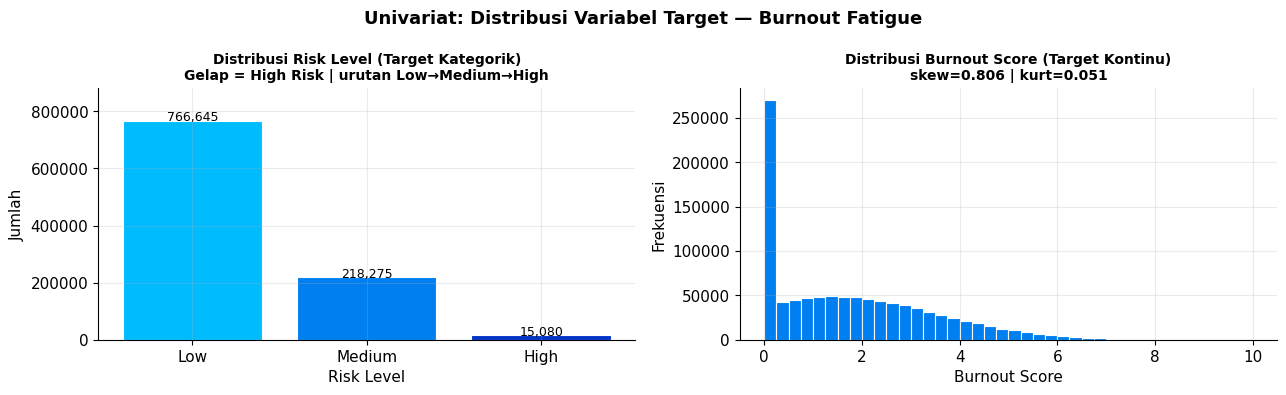

Risk Level: {'Low': 766645, 'Medium': 218275, 'High': 15080}
Burnout Score — mean=1.7841, median=1.4965, std=1.6640


In [4]:
if not df_burnout.empty and 'risk_level' in df_burnout.columns:
    risk_avail = [r for r in RISK_ORDER if r in df_burnout['risk_level'].unique()]
    rc = df_burnout['risk_level'].value_counts().reindex(risk_avail)
    n = len(rc)
    clrs = [PALETTE[int(i*(len(PALETTE)-1)/max(n-1,1))] for i in range(n)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    bars = axes[0].bar(rc.index, rc.values, color=clrs, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, rc.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                     f'{val:,}', ha='center', fontsize=9)
    axes[0].set_ylim(0, rc.max()*1.15)
    axes[0].set_xlabel('Risk Level'); axes[0].set_ylabel('Jumlah')
    axes[0].set_title('Distribusi Risk Level (Target Kategorik)\nGelap = High Risk | urutan Low→Medium→High',
                      fontsize=10, fontweight='bold')
    sns.despine(ax=axes[0])

    bs = df_burnout['burnout_score']
    axes[1].hist(bs.dropna(), bins=40, color=C_MID, edgecolor='white', linewidth=0.8)
    axes[1].set_xlabel('Burnout Score'); axes[1].set_ylabel('Frekuensi')
    axes[1].set_title(f'Distribusi Burnout Score (Target Kontinu)\nskew={bs.skew():.3f} | kurt={bs.kurtosis():.3f}',
                      fontsize=10, fontweight='bold')
    sns.despine(ax=axes[1])

    fig.suptitle('Univariat: Distribusi Variabel Target — Burnout Fatigue',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b1_uni_target.png', dpi=150, bbox_inches='tight'); plt.show()
    print(f'Risk Level: {rc.to_dict()}')
    print(f'Burnout Score — mean={bs.mean():.4f}, median={bs.median():.4f}, std={bs.std():.4f}')

**Target Burnout Fatigue:** Bar chart (risk_level kategorik) dan histogram (burnout_score kontinu). Warna gelap untuk High Risk sesuai *darker-is-more*.

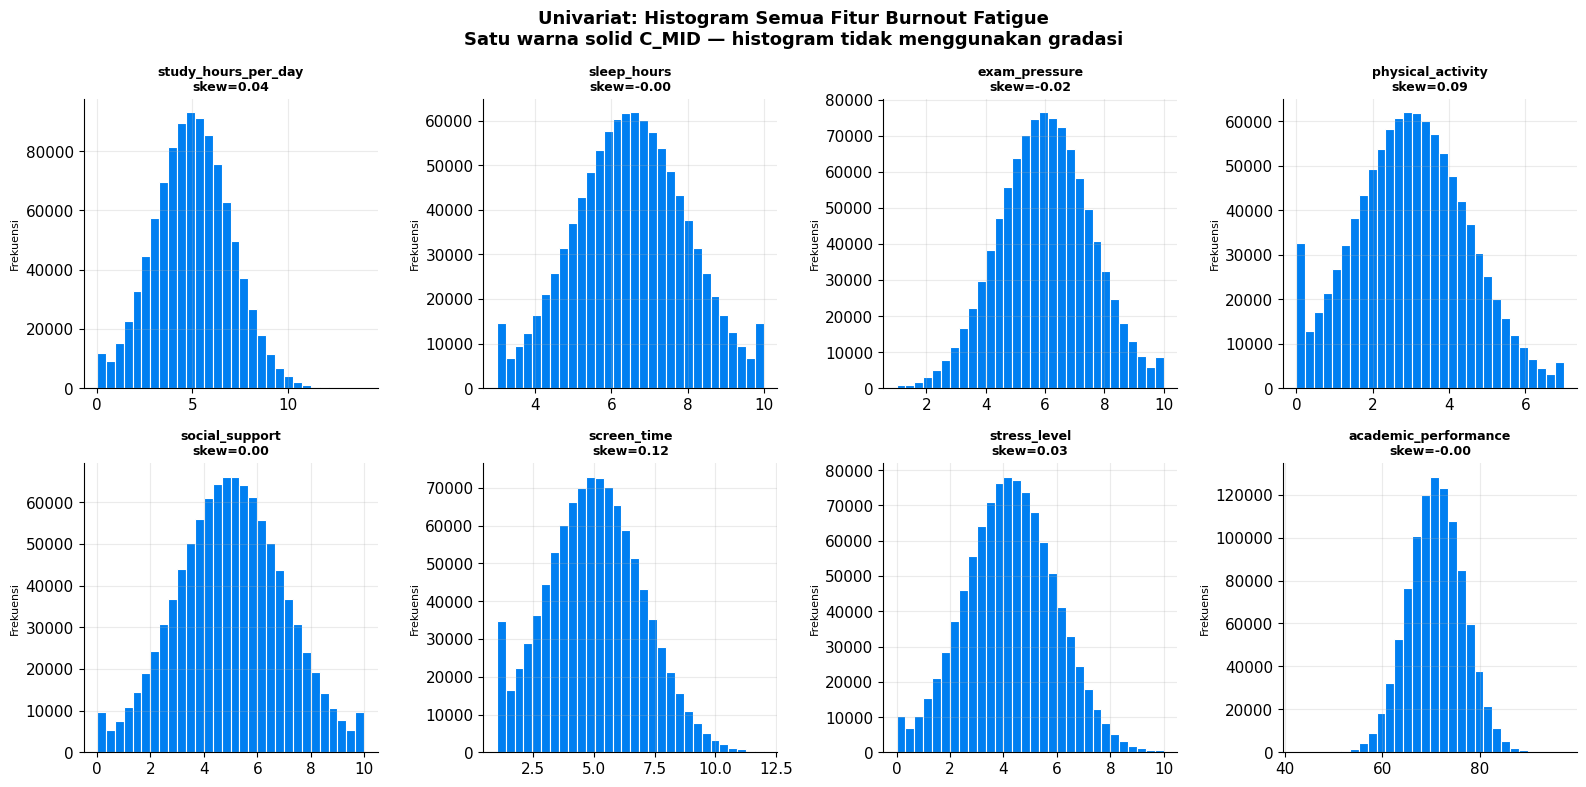

Skewness per fitur:
study_hours_per_day     0.0410
sleep_hours            -0.0010
exam_pressure          -0.0150
physical_activity       0.0940
social_support          0.0010
screen_time             0.1220
stress_level            0.0320
academic_performance   -0.0010
dtype: float64


In [5]:
if not df_burnout.empty:
    feat_b = [c for c in BURNOUT_FEAT if c in df_burnout.columns]
    n = len(feat_b); ncols = 4; nrows = (n+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
    axes = axes.flatten()
    for i, col in enumerate(feat_b):
        skv = df_burnout[col].skew()
        axes[i].hist(df_burnout[col].dropna(), bins=30, color=C_MID, edgecolor='white', linewidth=0.8)
        axes[i].set_title(f'{col}\nskew={skv:.2f}', fontsize=9, fontweight='bold')
        axes[i].set_ylabel('Frekuensi', fontsize=8)
        sns.despine(ax=axes[i])
    for j in range(n, len(axes)): axes[j].set_visible(False)
    fig.suptitle('Univariat: Histogram Semua Fitur Burnout Fatigue\nSatu warna solid C_MID — histogram tidak menggunakan gradasi',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b1_uni_hist_fitur.png', dpi=150, bbox_inches='tight'); plt.show()
    print('Skewness per fitur:')
    print(df_burnout[feat_b].skew().round(3))

**Histogram Fitur:** Satu warna solid `#007ff1` per histogram, tidak ada gradasi karena batang merepresentasikan rentang kontinu, bukan kategori berbeda.

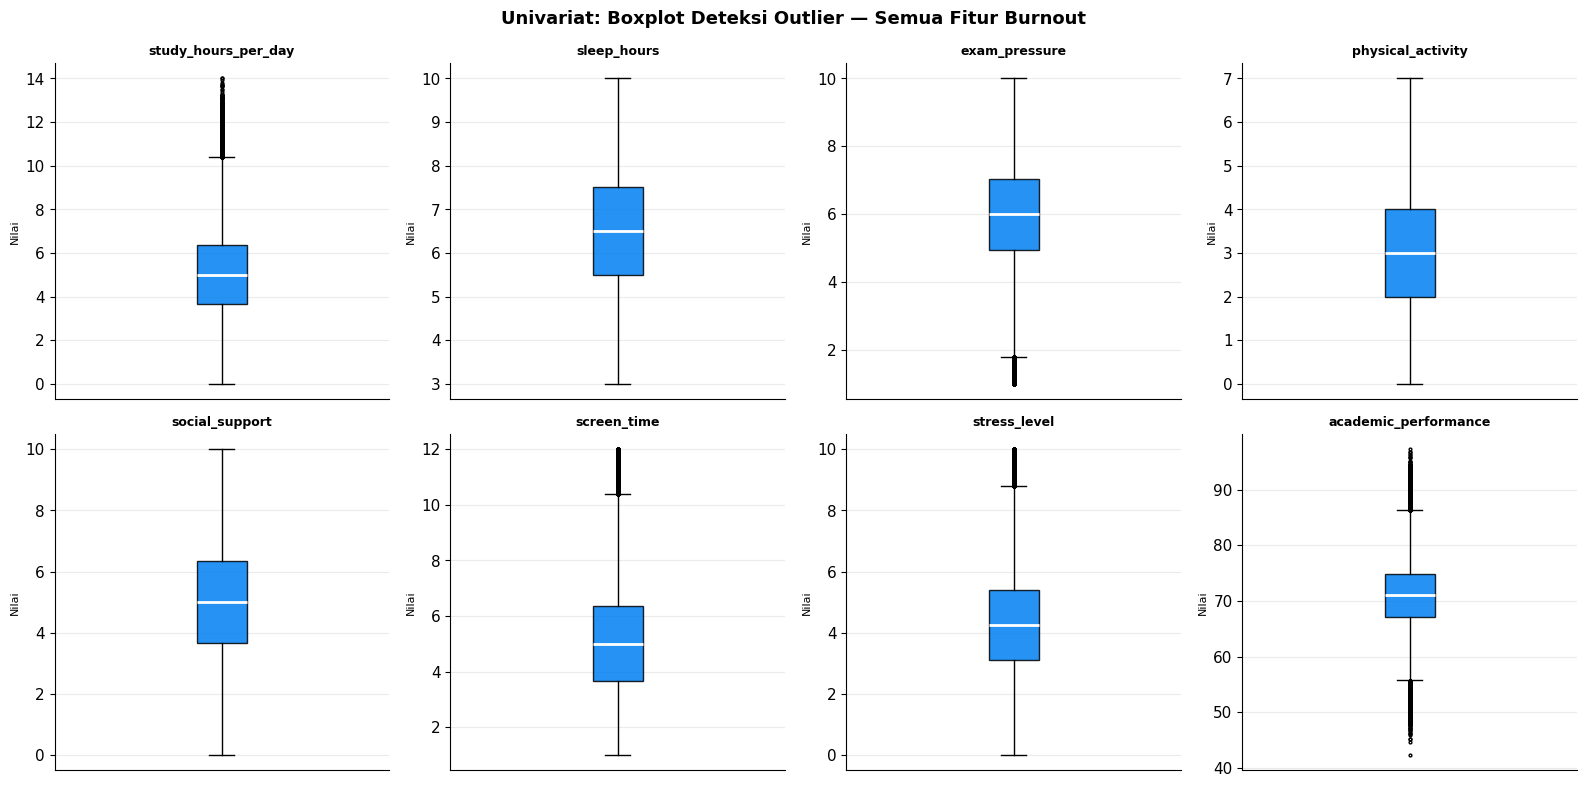

In [6]:
if not df_burnout.empty:
    feat_b = [c for c in BURNOUT_FEAT if c in df_burnout.columns]
    n = len(feat_b); ncols = 4; nrows = (n+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
    axes = axes.flatten()
    for i, col in enumerate(feat_b):
        bp = axes[i].boxplot(df_burnout[col].dropna(), patch_artist=True,
                              medianprops=dict(color='white', linewidth=2),
                              flierprops=dict(marker='o', markersize=2, color=C_DARK))
        bp['boxes'][0].set_facecolor(C_MID); bp['boxes'][0].set_alpha(0.85)
        axes[i].set_title(col, fontsize=9, fontweight='bold')
        axes[i].set_xticks([]); axes[i].set_ylabel('Nilai', fontsize=8)
        sns.despine(ax=axes[i])
    for j in range(n, len(axes)): axes[j].set_visible(False)
    fig.suptitle('Univariat: Boxplot Deteksi Outlier — Semua Fitur Burnout',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b1_uni_boxplot_outlier.png', dpi=150, bbox_inches='tight'); plt.show()

**Deteksi Outlier:** Boxplot menampilkan ringkasan 5-angka statistik. Titik di luar whisker = outlier yang perlu diinvestigasi.

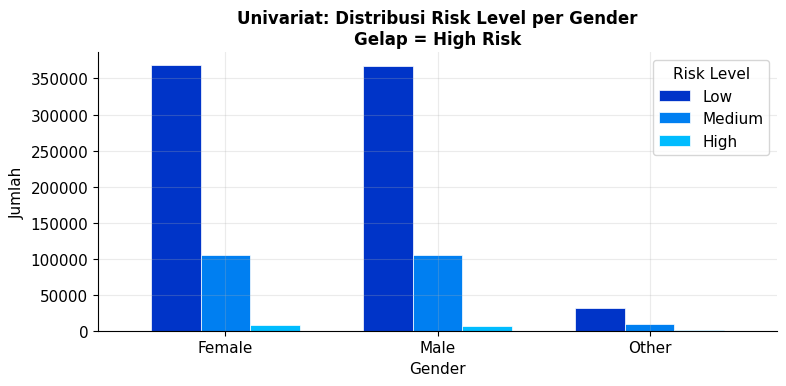

In [7]:
if not df_burnout.empty and 'gender' in df_burnout.columns and 'risk_level' in df_burnout.columns:
    risk_avail = [r for r in RISK_ORDER if r in df_burnout['risk_level'].unique()]
    pivot_g = df_burnout.groupby(['gender','risk_level']).size().unstack(fill_value=0)
    pivot_g = pivot_g[[c for c in risk_avail if c in pivot_g.columns]]
    n = len(pivot_g.columns)
    clrs = [PALETTE_R[int(i*(len(PALETTE_R)-1)/max(n-1,1))] for i in range(n)]

    fig, ax = plt.subplots(figsize=(8, 4))
    pivot_g.plot(kind='bar', ax=ax, color=clrs, edgecolor='white', linewidth=0.5, width=0.7)
    ax.set_xlabel('Gender'); ax.set_ylabel('Jumlah')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Risk Level')
    ax.set_title('Univariat: Distribusi Risk Level per Gender\nGelap = High Risk',
                 fontsize=12, fontweight='bold')
    sns.despine(ax=ax)
    plt.tight_layout(); plt.savefig('b1_uni_gender_risk.png', dpi=150, bbox_inches='tight'); plt.show()

**Risk Level per Gender:** Clustered bar chart membandingkan distribusi risk level antar kelompok gender.

### 1.3 Analisis Bivariat Burnout Fatigue

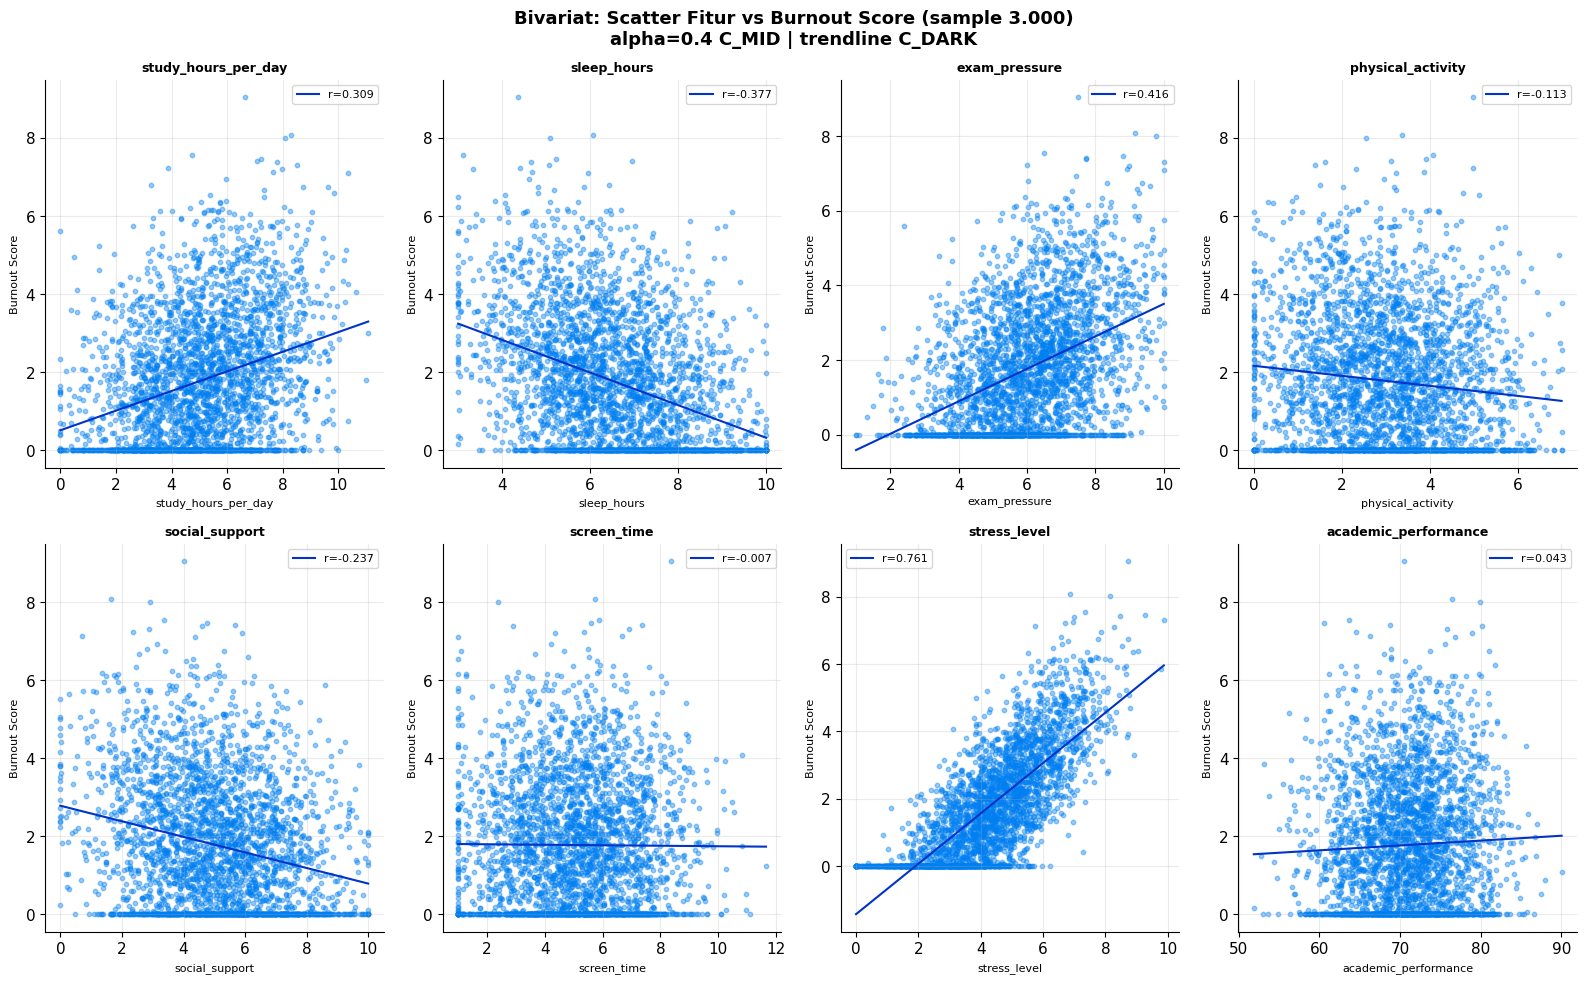

In [8]:
if not df_burnout.empty and 'burnout_score' in df_burnout.columns:
    feat_b = [c for c in BURNOUT_FEAT if c in df_burnout.columns]
    sample_b = df_burnout.sample(min(3000, len(df_burnout)), random_state=42)
    n = len(feat_b); ncols = 4; nrows = (n+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows))
    axes = axes.flatten()
    for i, col in enumerate(feat_b):
        valid = sample_b[[col,'burnout_score']].dropna()
        r = valid[col].corr(valid['burnout_score'])
        axes[i].scatter(valid[col], valid['burnout_score'], alpha=0.4, color=C_MID, s=10)
        m, b = np.polyfit(valid[col], valid['burnout_score'], 1)
        x_ = np.linspace(valid[col].min(), valid[col].max(), 100)
        axes[i].plot(x_, m*x_+b, color=C_DARK, linewidth=1.5, label=f'r={r:.3f}')
        axes[i].legend(fontsize=8); axes[i].set_title(col, fontsize=9, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=8); axes[i].set_ylabel('Burnout Score', fontsize=8)
        sns.despine(ax=axes[i])
    for j in range(n, len(axes)): axes[j].set_visible(False)
    fig.suptitle('Bivariat: Scatter Fitur vs Burnout Score (sample 3.000)\nalpha=0.4 C_MID | trendline C_DARK',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b1_biv_scatter.png', dpi=150, bbox_inches='tight'); plt.show()

**Scatter Fitur vs Target:** Alpha 0.4 menciptakan efek density, area padat otomatis terlihat gelap. Trendline `#0034c8` menunjukkan arah dan kekuatan korelasi Pearson.

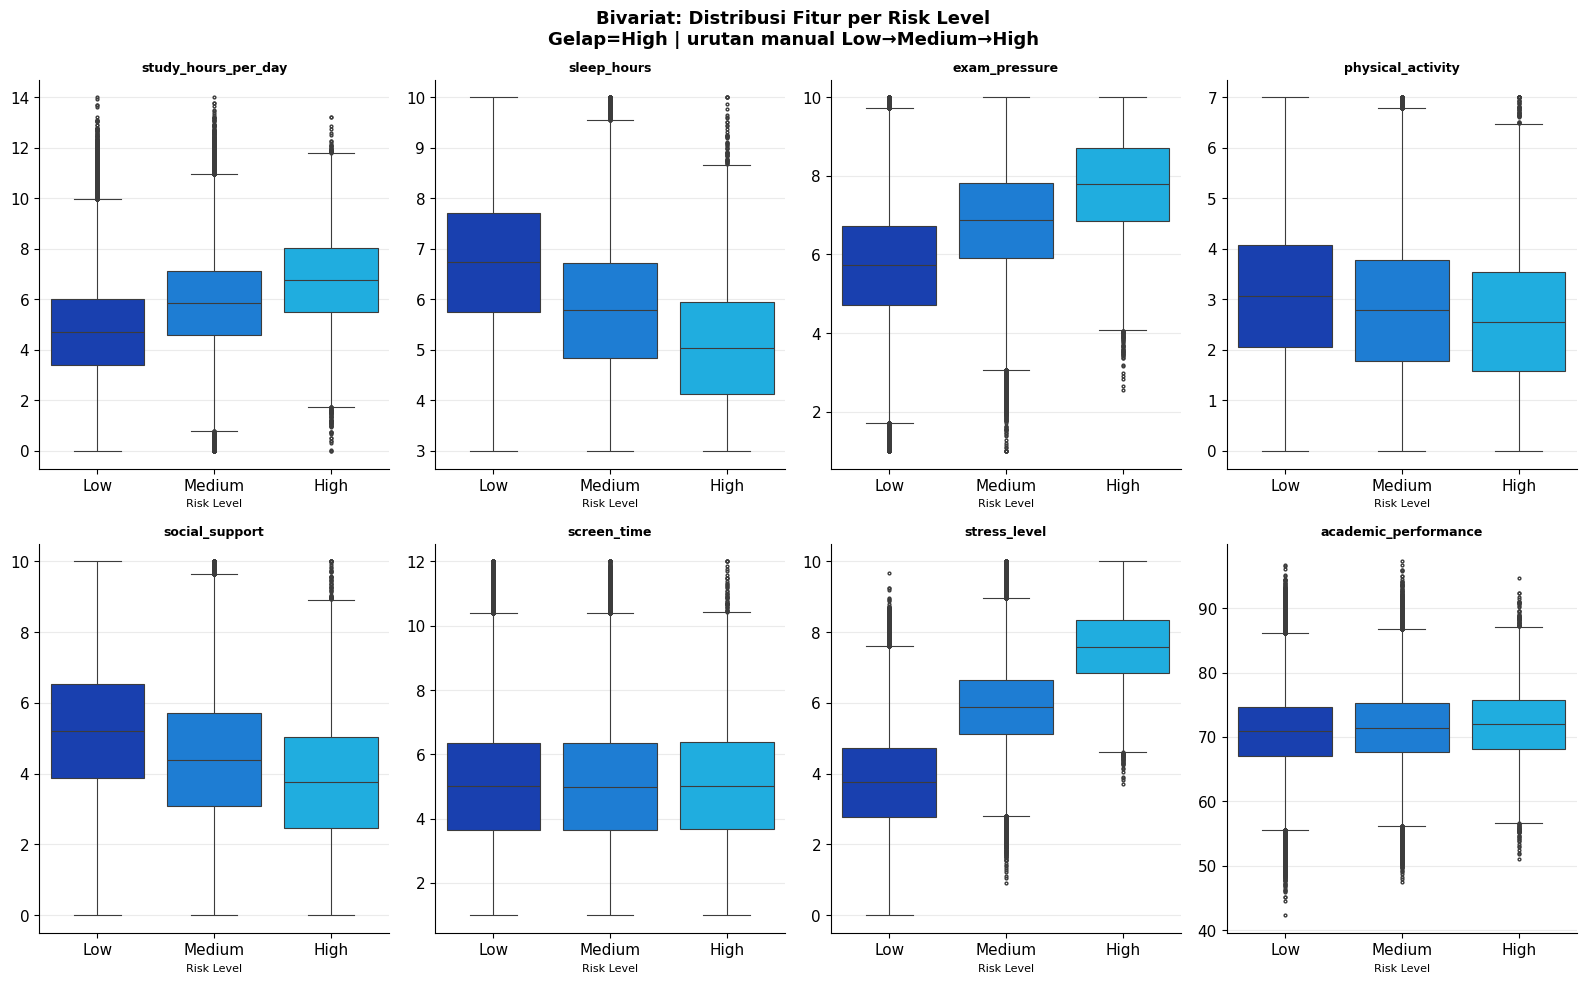

In [9]:
if not df_burnout.empty and 'risk_level' in df_burnout.columns:
    feat_b = [c for c in BURNOUT_FEAT if c in df_burnout.columns]
    risk_avail = [r for r in RISK_ORDER if r in df_burnout['risk_level'].unique()]
    n = len(risk_avail)
    pal_r = {r: PALETTE_R[int(i*(len(PALETTE_R)-1)/max(n-1,1))] for i,r in enumerate(risk_avail)}
    n_feat = len(feat_b); ncols = 4; nrows = (n_feat+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows))
    axes = axes.flatten()
    for i, col in enumerate(feat_b):
        sns.boxplot(data=df_burnout, x='risk_level', y=col,
                    hue='risk_level', order=risk_avail, hue_order=risk_avail,
                    palette=pal_r, legend=False, ax=axes[i],
                    linewidth=0.8, flierprops=dict(marker='o', markersize=2))
        axes[i].set_title(col, fontsize=9, fontweight='bold')
        axes[i].set_xlabel('Risk Level', fontsize=8); axes[i].set_ylabel('', fontsize=8)
        sns.despine(ax=axes[i])
    for j in range(n_feat, len(axes)): axes[j].set_visible(False)
    fig.suptitle('Bivariat: Distribusi Fitur per Risk Level\nGelap=High | urutan manual Low→Medium→High',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b1_biv_boxplot_risk.png', dpi=150, bbox_inches='tight'); plt.show()

**Fitur per Risk Level:** Small multiples boxplot dengan sumbu Y mandiri per panel. Pola berbeda antar risk level menunjukkan fitur yang punya daya diskriminasi tinggi.

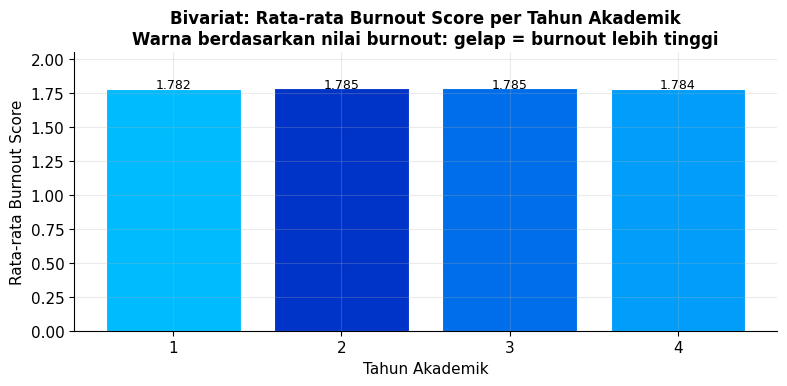

academic_year
1   1.7815
2   1.7853
3   1.7852
4   1.7843
Name: burnout_score, dtype: float64


In [10]:
if not df_burnout.empty and 'academic_year' in df_burnout.columns and 'burnout_score' in df_burnout.columns:
    yr_mean = df_burnout.groupby('academic_year')['burnout_score'].mean().sort_index()
    n = len(yr_mean)
    # Darker-is-more: nilai burnout tertinggi = warna paling gelap
    # Rank setiap tahun berdasarkan nilai burnout, bukan posisi urutan
    ranks = yr_mean.rank(method='min').astype(int) - 1
    clrs = [PALETTE[int(r*(len(PALETTE)-1)/max(n-1,1))] for r in ranks]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(yr_mean.index.astype(str), yr_mean.values, color=clrs,
                  edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, yr_mean.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', fontsize=9)
    ax.set_ylim(0, yr_mean.max()*1.15)
    ax.set_xlabel('Tahun Akademik'); ax.set_ylabel('Rata-rata Burnout Score')
    ax.set_title('Bivariat: Rata-rata Burnout Score per Tahun Akademik\nWarna berdasarkan nilai burnout: gelap = burnout lebih tinggi',
                 fontsize=12, fontweight='bold')
    sns.despine(ax=ax)
    plt.tight_layout(); plt.savefig('b1_biv_year_burnout.png', dpi=150, bbox_inches='tight'); plt.show()
    print(yr_mean.round(4))

**Burnout per Tahun Akademik:** Bar diurutkan berdasarkan tahun dan warna mengikuti nilai rata-rata (lebih gelap = burnout lebih tinggi). Pola meningkat seiring tahun menunjukkan akumulasi tekanan studi.

### 1.4 Analisis Multivariat Burnout Fatigue

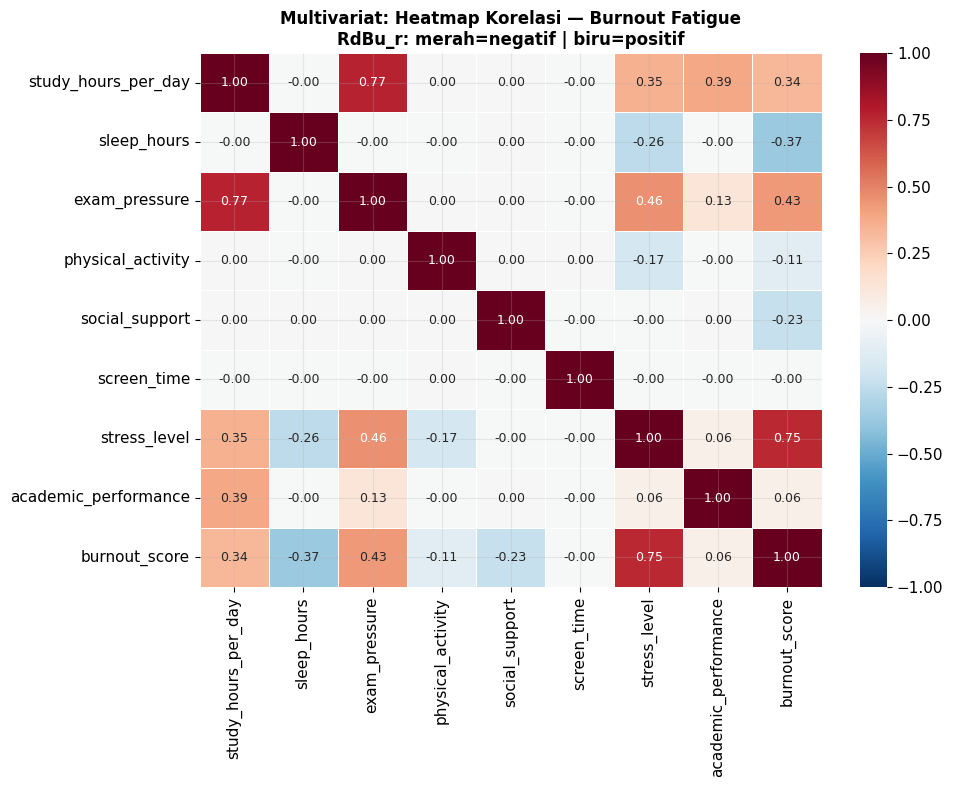

Korelasi terhadap burnout_score:
stress_level            0.7530
exam_pressure           0.4340
study_hours_per_day     0.3350
academic_performance    0.0570
screen_time            -0.0010
physical_activity      -0.1100
social_support         -0.2300
sleep_hours            -0.3710
Name: burnout_score, dtype: float64


In [11]:
if not df_burnout.empty:
    feat_b = [c for c in BURNOUT_FEAT + ['burnout_score'] if c in df_burnout.columns]
    corr_b = df_burnout[feat_b].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_b, annot=True, fmt='.2f', cmap=HEATMAP_DIV,
                vmin=-1, vmax=1, center=0,
                linewidths=0.5, linecolor='white', ax=ax, annot_kws={'size': 9})
    ax.set_title('Multivariat: Heatmap Korelasi — Burnout Fatigue\nRdBu_r: merah=negatif | biru=positif',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.savefig('b1_multi_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    if 'burnout_score' in corr_b.columns:
        print('Korelasi terhadap burnout_score:')
        print(corr_b['burnout_score'].drop('burnout_score').sort_values(ascending=False).round(3))

**Heatmap Korelasi:** `RdBu_r` wajib digunakan untuk korelasi karena mencakup nilai -1 hingga +1. Biru = positif, merah = negatif, putih = nol.

In [12]:
if not df_burnout.empty:
    feat_vif = [c for c in BURNOUT_FEAT if c in df_burnout.columns]
    Xv = df_burnout[feat_vif].dropna().sample(min(10000, len(df_burnout)), random_state=42)
    vif_df = pd.DataFrame({
        'Fitur': feat_vif,
        'VIF'  : [variance_inflation_factor(Xv.values, i) for i in range(len(feat_vif))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    print('VIF Check (aman < 10 untuk model linear):')
    print(vif_df.round(2))
    flag = vif_df[vif_df['VIF'] >= 10]
    print(f'\nMultikolinearitas tinggi (VIF>=10): {flag["Fitur"].tolist() if len(flag)>0 else "Tidak ada"}')

VIF Check (aman < 10 untuk model linear):
                  Fitur     VIF
0  academic_performance 48.1700
1         exam_pressure 41.1000
2           sleep_hours 20.2300
3   study_hours_per_day 17.9900
4          stress_level 10.1500
5           screen_time  7.5700
6        social_support  7.2300
7     physical_activity  5.3300

Multikolinearitas tinggi (VIF>=10): ['academic_performance', 'exam_pressure', 'sleep_hours', 'study_hours_per_day', 'stress_level']


**VIF:** Fitur dengan VIF ≥ 10 perlu ditangani sebelum model linear — hapus salah satu atau gabungkan dengan PCA.

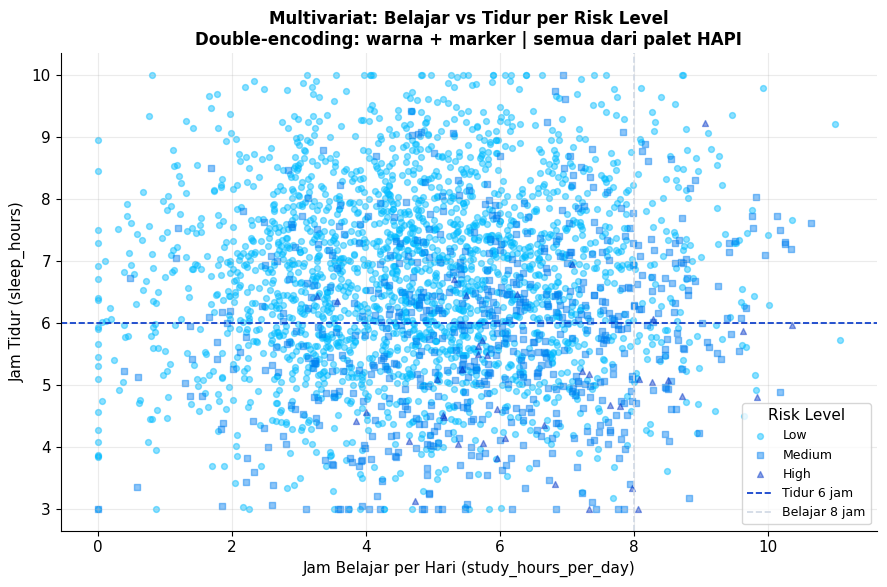

In [13]:
if not df_burnout.empty and 'risk_level' in df_burnout.columns:
    feat_b = [c for c in ['study_hours_per_day','sleep_hours'] if c in df_burnout.columns]
    if len(feat_b) == 2:
        sample_b3 = df_burnout.sample(min(3000, len(df_burnout)), random_state=42)
        risk_avail = [r for r in RISK_ORDER if r in sample_b3['risk_level'].unique()]
        cmap3 = {'Low': C_LIGHT, 'Medium': C_MID, 'High': C_DARK}
        mkr3  = {'Low': 'o', 'Medium': 's', 'High': '^'}
        fig, ax = plt.subplots(figsize=(9, 6))
        for rl in risk_avail:
            mask = sample_b3['risk_level'] == rl
            ax.scatter(sample_b3.loc[mask,'study_hours_per_day'],
                       sample_b3.loc[mask,'sleep_hours'],
                       c=cmap3.get(rl, C_MID), marker=mkr3.get(rl,'o'),
                       alpha=0.45, s=18, label=rl)
        ax.axhline(6, color=C_DARK, linestyle='--', linewidth=1.2, label='Tidur 6 jam')
        ax.axvline(8, color=C_GREY, linestyle='--', linewidth=1.2, label='Belajar 8 jam')
        ax.set_xlabel('Jam Belajar per Hari (study_hours_per_day)')
        ax.set_ylabel('Jam Tidur (sleep_hours)')
        ax.legend(title='Risk Level', fontsize=9)
        ax.set_title('Multivariat: Belajar vs Tidur per Risk Level\nDouble-encoding: warna + marker | semua dari palet HAPI',
                     fontsize=12, fontweight='bold')
        sns.despine(ax=ax)
        plt.tight_layout(); plt.savefig('b1_multi_scatter3var.png', dpi=150, bbox_inches='tight'); plt.show()

**Scatter 3 Variabel:** Low=`#00bcff`, Medium=`#007ff1`, High=`#0034c8` semua dari palet HAPI. Double-encoding (warna + marker shape) memudahkan pemisahan kelompok.

### Dataset 2: Student Lifestyle
**Kolom:** `Study_Hours_Per_Day`, `Sleep_Hours_Per_Day`, `Physical_Activity_Hours_Per_Day`, `Extracurricular_Hours_Per_Day`, `Social_Hours_Per_Day` → target: `Stress_Level`

### 2.1 Data Profiling & Assessing

In [14]:
if not df_lifestyle.empty:
    feat_ls = [c for c in LIFESTYLE_FEAT if c in df_lifestyle.columns]
    print('Shape   :', df_lifestyle.shape)
    print('Kolom   :', df_lifestyle.columns.tolist())
    print('Missing :', df_lifestyle.isnull().sum().sum())
    print('Duplikat:', df_lifestyle.duplicated().sum())
    print('\nStatistik Deskriptif:')
    cols_desc = feat_ls + (['Stress_Level'] if 'Stress_Level' in df_lifestyle.columns else [])
    print(df_lifestyle[cols_desc].describe().round(3))

Shape   : (2000, 6)
Kolom   : ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Stress_Level']
Missing : 0
Duplikat: 1

Statistik Deskriptif:
       Study_Hours_Per_Day  Sleep_Hours_Per_Day  \
count            2000.0000            2000.0000   
mean                7.4760               7.5010   
std                 1.4240               1.4610   
min                 5.0000               5.0000   
25%                 6.3000               6.2000   
50%                 7.4000               7.5000   
75%                 8.7000               8.8000   
max                10.0000              10.0000   

       Physical_Activity_Hours_Per_Day  Extracurricular_Hours_Per_Day  \
count                        2000.0000                      2000.0000   
mean                            4.2220                         1.9900   
std                             2.3070                         1.1560   
min             

In [15]:
if not df_lifestyle.empty and 'Stress_Level' in df_lifestyle.columns:
    print('Nilai unik Stress_Level:', df_lifestyle['Stress_Level'].unique())
    print('Tipe data:', df_lifestyle['Stress_Level'].dtype)
    STRESS_ORDER_LS = ['Low', 'Moderate', 'High']
    STRESS_ENCODE   = {'Low': 1, 'Moderate': 2, 'High': 3}
    df_lifestyle['Stress_Level_num'] = df_lifestyle['Stress_Level'].map(STRESS_ENCODE)
    n_encoded = df_lifestyle['Stress_Level_num'].notna().sum()
    print(f'Berhasil di-encode: {n_encoded}/{len(df_lifestyle)} baris')
    print(df_lifestyle['Stress_Level'].value_counts())

Nilai unik Stress_Level: ['Moderate' 'High' 'Low']
Tipe data: object
Berhasil di-encode: 2000/2000 baris
Stress_Level
High        1029
Moderate     674
Low          297
Name: count, dtype: int64


**Encoding Stress_Level**

Kolom `Stress_Level` bertipe string ordinal (`'Low'`, `'Moderate'`, `'High'`), bukan numerik. Encoding: Low=1, Moderate=2, High=3. Kolom `Stress_Level_num` digunakan untuk operasi numerik (scatter, heatmap korelasi, histogram), sedangkan kolom string asli digunakan untuk visualisasi kategorik (bar chart, boxplot label).

### 2.2 Analisis Univariat Student Lifestyle

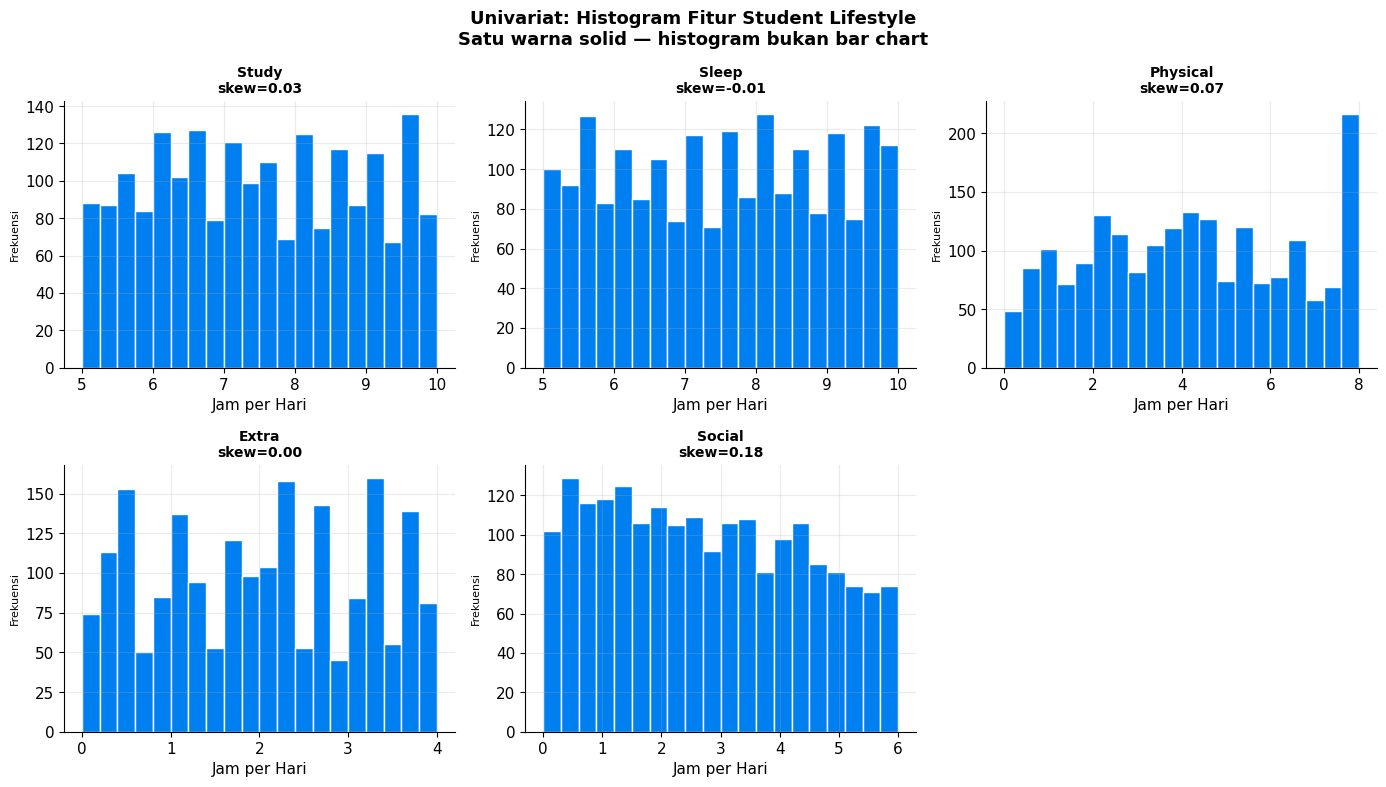

Skewness:
Study_Hours_Per_Day                0.0350
Sleep_Hours_Per_Day               -0.0070
Physical_Activity_Hours_Per_Day    0.0720
Extracurricular_Hours_Per_Day      0.0010
Social_Hours_Per_Day               0.1840
dtype: float64


In [16]:
if not df_lifestyle.empty:
    feat_ls = [c for c in LIFESTYLE_FEAT if c in df_lifestyle.columns]
    n = len(feat_ls); ncols = 3; nrows = (n+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
    axes = axes.flatten()
    for i, col in enumerate(feat_ls):
        skv = df_lifestyle[col].skew()
        axes[i].hist(df_lifestyle[col].dropna(), bins=20, color=C_MID,
                     edgecolor='white', linewidth=1.0)
        axes[i].set_title(f'{LIFESTYLE_SHORT.get(col,col)}\nskew={skv:.2f}',
                          fontsize=10, fontweight='bold')
        axes[i].set_xlabel('Jam per Hari'); axes[i].set_ylabel('Frekuensi', fontsize=8)
        sns.despine(ax=axes[i])
    for j in range(n, len(axes)): axes[j].set_visible(False)
    fig.suptitle('Univariat: Histogram Fitur Student Lifestyle\nSatu warna solid — histogram bukan bar chart',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b2_uni_hist.png', dpi=150, bbox_inches='tight'); plt.show()
    print('Skewness:')
    print(df_lifestyle[feat_ls].skew().round(3))

**Histogram Fitur Lifestyle:** Kolom menggunakan nama persis dari CSV seperti `Study_Hours_Per_Day`.

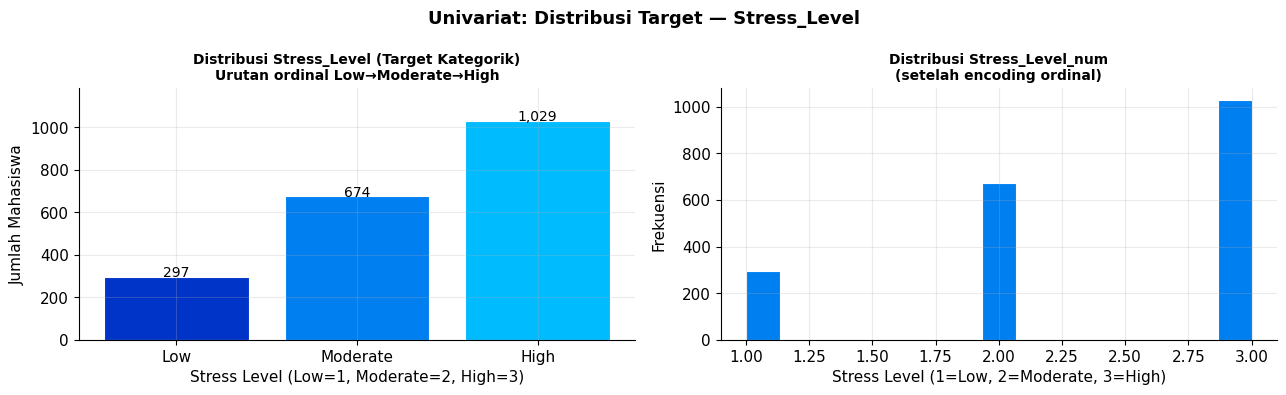

Distribusi:
Stress_Level
Low          297
Moderate     674
High        1029
Name: count, dtype: int64


In [17]:
if not df_lifestyle.empty and 'Stress_Level' in df_lifestyle.columns:
    stress_avail = [s for s in STRESS_ORDER_LS if s in df_lifestyle['Stress_Level'].unique()]
    rc_sl = df_lifestyle['Stress_Level'].value_counts().reindex(stress_avail)
    n = len(rc_sl)
    clrs_sl = [PALETTE_R[int(i*(len(PALETTE_R)-1)/max(n-1,1))] for i in range(n)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    bars = axes[0].bar(rc_sl.index, rc_sl.values, color=clrs_sl,
                       edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, rc_sl.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                     f'{val:,}', ha='center', fontsize=10)
    axes[0].set_ylim(0, rc_sl.max()*1.15)
    axes[0].set_xlabel('Stress Level (Low=1, Moderate=2, High=3)')
    axes[0].set_ylabel('Jumlah Mahasiswa')
    axes[0].set_title('Distribusi Stress_Level (Target Kategorik)\nUrutan ordinal Low→Moderate→High',
                      fontsize=10, fontweight='bold')
    sns.despine(ax=axes[0])

    if 'Stress_Level_num' in df_lifestyle.columns:
        sl_num = df_lifestyle['Stress_Level_num'].dropna()
        axes[1].hist(sl_num, bins=15, color=C_MID, edgecolor='white', linewidth=0.8)
        axes[1].set_xlabel('Stress Level (1=Low, 2=Moderate, 3=High)')
        axes[1].set_ylabel('Frekuensi')
        axes[1].set_title('Distribusi Stress_Level_num\n(setelah encoding ordinal)',
                          fontsize=10, fontweight='bold')
        sns.despine(ax=axes[1])

    fig.suptitle('Univariat: Distribusi Target — Stress_Level', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('b2_uni_target.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Distribusi:')
    print(rc_sl)

**Target Stress_Level:** Nilai kontinu numerik. Skewness dan boxplot menentukan apakah transformasi log diperlukan sebelum model regresi.

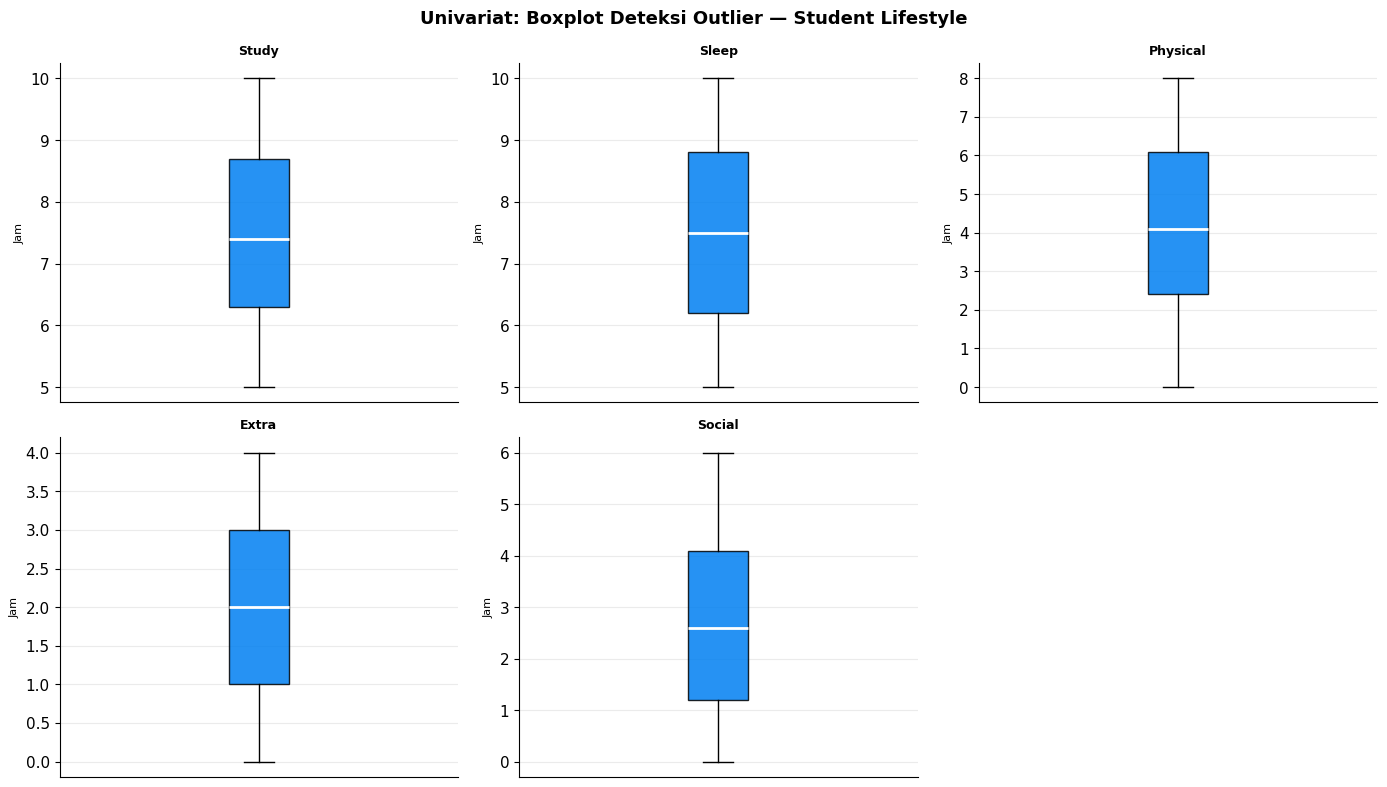

In [18]:
if not df_lifestyle.empty:
    feat_ls = [c for c in LIFESTYLE_FEAT if c in df_lifestyle.columns]
    n = len(feat_ls); ncols = 3; nrows = (n+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
    axes = axes.flatten()
    for i, col in enumerate(feat_ls):
        bp = axes[i].boxplot(df_lifestyle[col].dropna(), patch_artist=True,
                              medianprops=dict(color='white', linewidth=2),
                              flierprops=dict(marker='o', markersize=3, color=C_DARK))
        bp['boxes'][0].set_facecolor(C_MID); bp['boxes'][0].set_alpha(0.85)
        axes[i].set_title(LIFESTYLE_SHORT.get(col,col), fontsize=9, fontweight='bold')
        axes[i].set_xticks([]); axes[i].set_ylabel('Jam', fontsize=8)
        sns.despine(ax=axes[i])
    for j in range(n, len(axes)): axes[j].set_visible(False)
    fig.suptitle('Univariat: Boxplot Deteksi Outlier — Student Lifestyle',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b2_uni_boxplot.png', dpi=150, bbox_inches='tight'); plt.show()

**Deteksi Outlier Lifestyle:** Jam > 16 per hari tidak realistis secara fisik, outlier seperti ini merupakan error input yang perlu dihapus atau di-clip.

### 2.3 Analisis Bivariat Student Lifestyle

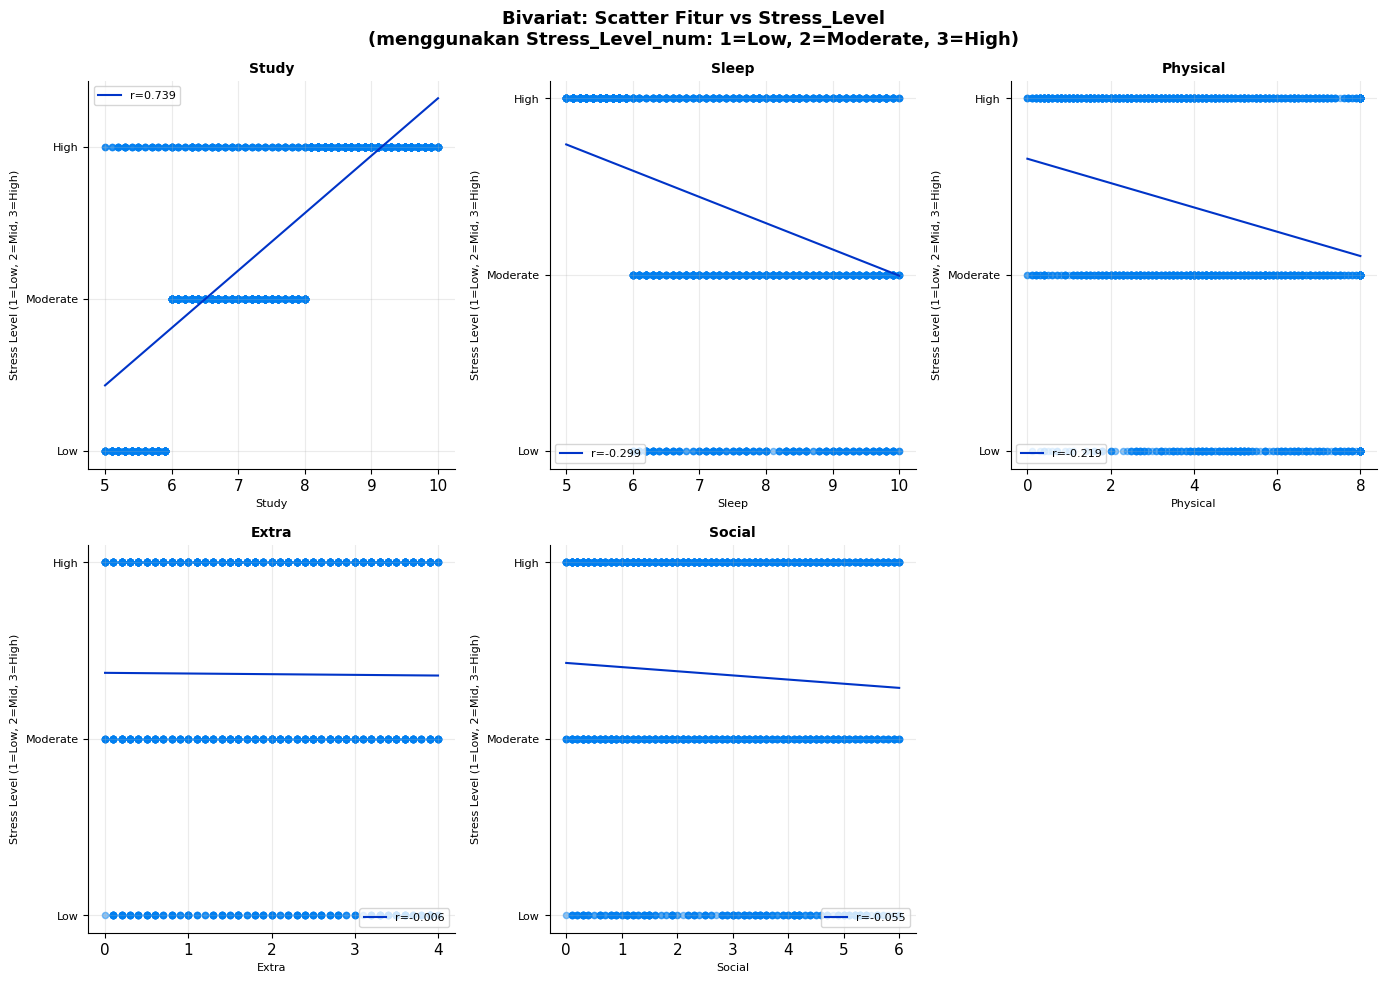

In [19]:
if not df_lifestyle.empty and 'Stress_Level_num' in df_lifestyle.columns:
    feat_ls = [c for c in LIFESTYLE_FEAT if c in df_lifestyle.columns]
    n = len(feat_ls); ncols = 3; nrows = (n+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5*nrows))
    axes = axes.flatten()
    for i, col in enumerate(feat_ls):
        valid = df_lifestyle[[col,'Stress_Level_num']].dropna()
        r = valid[col].corr(valid['Stress_Level_num'])
        axes[i].scatter(valid[col], valid['Stress_Level_num'],
                        alpha=0.45, color=C_MID, s=20)
        m, b = np.polyfit(valid[col], valid['Stress_Level_num'], 1)
        x_ = np.linspace(valid[col].min(), valid[col].max(), 100)
        axes[i].plot(x_, m*x_+b, color=C_DARK, linewidth=1.5, label=f'r={r:.3f}')
        axes[i].legend(fontsize=8)
        axes[i].set_title(LIFESTYLE_SHORT.get(col,col), fontsize=10, fontweight='bold')
        axes[i].set_xlabel(LIFESTYLE_SHORT.get(col,col), fontsize=8)
        axes[i].set_ylabel('Stress Level (1=Low, 2=Mid, 3=High)', fontsize=8)
        axes[i].set_yticks([1, 2, 3])
        axes[i].set_yticklabels(['Low', 'Moderate', 'High'], fontsize=8)
        sns.despine(ax=axes[i])
    for j in range(n, len(axes)): axes[j].set_visible(False)
    fig.suptitle('Bivariat: Scatter Fitur vs Stress_Level\n(menggunakan Stress_Level_num: 1=Low, 2=Moderate, 3=High)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('b2_biv_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

**Scatter Numerik vs Numerik:** Korelasi Pearson `r` dan trendline ditampilkan untuk setiap fitur vs target.

### 2.4 Analisis Multivariat Student Lifestyle

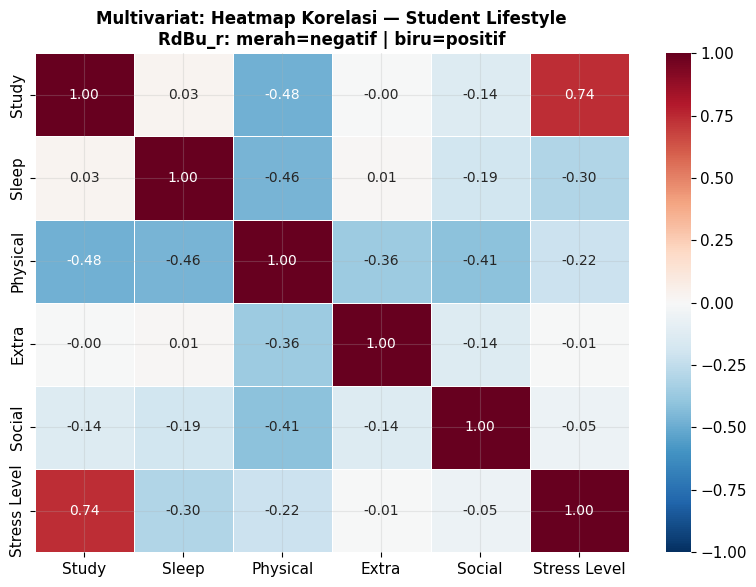

Korelasi terhadap Stress Level:
Study       0.7390
Extra      -0.0060
Social     -0.0550
Physical   -0.2190
Sleep      -0.2990
Name: Stress Level, dtype: float64


In [20]:
if not df_lifestyle.empty and 'Stress_Level_num' in df_lifestyle.columns:
    feat_ls = [c for c in LIFESTYLE_FEAT if c in df_lifestyle.columns]
    all_ls  = feat_ls + ['Stress_Level_num']
    corr_ls = df_lifestyle[all_ls].corr()
    short_idx = {c: LIFESTYLE_SHORT.get(c,c) for c in feat_ls}
    short_idx['Stress_Level_num'] = 'Stress Level'
    corr_ls = corr_ls.rename(index=short_idx, columns=short_idx)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr_ls, annot=True, fmt='.2f', cmap=HEATMAP_DIV,
                vmin=-1, vmax=1, center=0,
                linewidths=0.5, linecolor='white', ax=ax, annot_kws={'size': 10})
    ax.set_title('Multivariat: Heatmap Korelasi — Student Lifestyle\nRdBu_r: merah=negatif | biru=positif',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('b2_multi_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    if 'Stress Level' in corr_ls.columns:
        print('Korelasi terhadap Stress Level:')
        print(corr_ls['Stress Level'].drop('Stress Level').sort_values(ascending=False).round(3))

**Heatmap Korelasi Lifestyle:** Nama kolom dipersingkat untuk keterbacaan. Fitur dengan korelasi absolut tertinggi terhadap `Stress Level` adalah prediktor paling relevan.

In [21]:
if not df_lifestyle.empty:
    feat_ls = [c for c in LIFESTYLE_FEAT if c in df_lifestyle.columns]
    if len(feat_ls) >= 2:
        Xv = df_lifestyle[feat_ls].dropna()
        vif_ls = pd.DataFrame({
            'Fitur': [LIFESTYLE_SHORT.get(c,c) for c in feat_ls],
            'VIF'  : [variance_inflation_factor(Xv.values, i) for i in range(len(feat_ls))]
        }).sort_values('VIF', ascending=False).reset_index(drop=True)
        print('VIF Check - Student Lifestyle:')
        print(vif_ls.round(2))

VIF Check - Student Lifestyle:
      Fitur     VIF
0     Study 17.1100
1     Sleep 16.5800
2     Extra  3.8300
3  Physical  3.2500
4    Social  3.1700


**VIF Lifestyle:** Dataset jam aktivitas dapat mengalami multikolinearitas jika total jam mendekati 24 jam — VIF check mengidentifikasi fitur redundan.

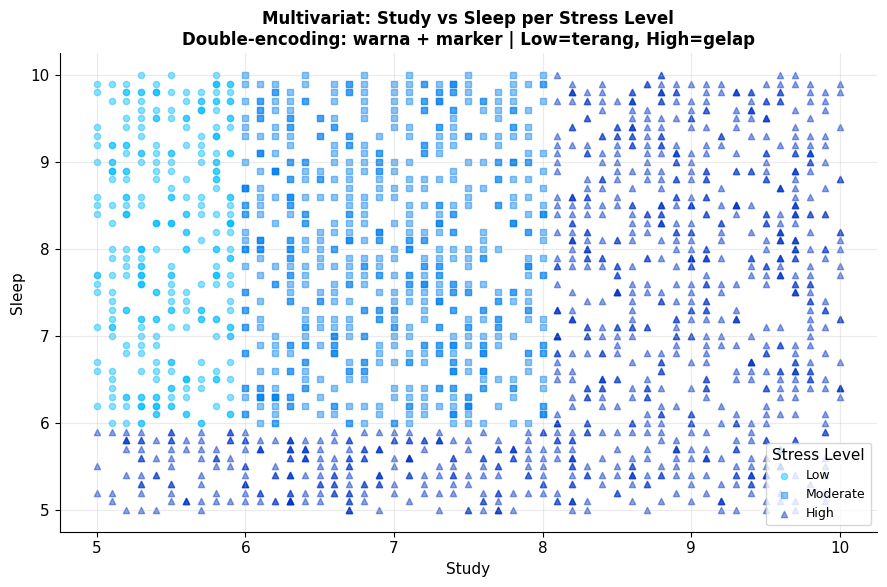

In [22]:
if not df_lifestyle.empty and 'Stress_Level_num' in df_lifestyle.columns:
    feat_ls = [c for c in LIFESTYLE_FEAT if c in df_lifestyle.columns]
    if len(feat_ls) >= 2:
        col_x, col_y = feat_ls[0], feat_ls[1]
        valid = df_lifestyle[[col_x, col_y, 'Stress_Level', 'Stress_Level_num']].dropna()
        cmap3 = {'Low': C_LIGHT, 'Moderate': C_MID, 'High': C_DARK}
        mkr3  = {'Low': 'o', 'Moderate': 's', 'High': '^'}
        stress_avail = [s for s in STRESS_ORDER_LS if s in valid['Stress_Level'].unique()]

        fig, ax = plt.subplots(figsize=(9, 6))
        for grp in stress_avail:
            mask = valid['Stress_Level'] == grp
            ax.scatter(valid.loc[mask, col_x], valid.loc[mask, col_y],
                       c=cmap3.get(grp, C_MID), marker=mkr3.get(grp, 'o'),
                       alpha=0.45, s=20, label=grp)
        ax.set_xlabel(LIFESTYLE_SHORT.get(col_x, col_x))
        ax.set_ylabel(LIFESTYLE_SHORT.get(col_y, col_y))
        ax.legend(title='Stress Level', fontsize=9)
        ax.set_title(f'Multivariat: {LIFESTYLE_SHORT.get(col_x,col_x)} vs {LIFESTYLE_SHORT.get(col_y,col_y)} per Stress Level\nDouble-encoding: warna + marker | Low=terang, High=gelap',
                     fontsize=12, fontweight='bold')
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.savefig('b2_multi_scatter3var.png', dpi=150, bbox_inches='tight')
        plt.show()

**Scatter 3 Variabel Lifestyle:** `Stress_Level` dikuartilkan menjadi 3 kelompok untuk visualisasi. Double-encoding memudahkan pemisahan visual.

### Dataset 3: MBI Questions
**Kolom:** `EX1–EX5` (Exhaustion), `CY1–CY4` (Cynicism), `EF1–EF6` (Efficacy) → target: `fatigue_score`, `risk_level`

### 3.1 Data Profiling & Assessing

In [23]:
if not df_mbi.empty:
    mbi_ex = [c for c in MBI_EX if c in df_mbi.columns]
    mbi_cy = [c for c in MBI_CY if c in df_mbi.columns]
    mbi_ef = [c for c in MBI_EF if c in df_mbi.columns]
    print('Shape   :', df_mbi.shape)
    print('Kolom   :', df_mbi.columns.tolist())
    print('Missing :', df_mbi.isnull().sum().sum())
    print('Duplikat:', df_mbi.duplicated().sum())
    print(f'\nItem EX ({len(mbi_ex)}): {mbi_ex}')
    print(f'Item CY ({len(mbi_cy)}): {mbi_cy}')
    print(f'Item EF ({len(mbi_ef)}): {mbi_ef}')
    all_items = mbi_ex + mbi_cy + mbi_ef
    print('\nStatistik Deskriptif Item MBI:')
    print(df_mbi[all_items].describe().round(3))

Shape   : (9998, 18)
Kolom   : ['student_id', 'EX1', 'EX2', 'EX3', 'EX4', 'EX5', 'CY1', 'CY2', 'CY3', 'CY4', 'EF1', 'EF2', 'EF3', 'EF4', 'EF5', 'EF6', 'fatigue_score', 'risk_level']
Missing : 0
Duplikat: 0

Item EX (5): ['EX1', 'EX2', 'EX3', 'EX4', 'EX5']
Item CY (4): ['CY1', 'CY2', 'CY3', 'CY4']
Item EF (6): ['EF1', 'EF2', 'EF3', 'EF4', 'EF5', 'EF6']

Statistik Deskriptif Item MBI:
            EX1       EX2       EX3       EX4       EX5       CY1       CY2  \
count 9998.0000 9998.0000 9998.0000 9998.0000 9998.0000 9998.0000 9998.0000   
mean     2.7370    2.7470    2.7360    2.7590    2.7400    2.6100    2.5940   
std      1.7720    1.7710    1.7540    1.7670    1.7570    1.7390    1.7230   
min      0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000   
25%      1.0000    1.0000    1.0000    1.0000    1.0000    1.0000    1.0000   
50%      3.0000    3.0000    3.0000    3.0000    3.0000    2.0000    2.0000   
75%      4.0000    4.0000    4.0000    4.0000    4.0000    4.

**Profiling MBI:** Semua item EX/CY/EF adalah skala Likert 0–6. `fatigue_score` adalah skor gabungan, `risk_level` adalah label kategorik.

### 3.2 Analisis Univariat MBI Questions

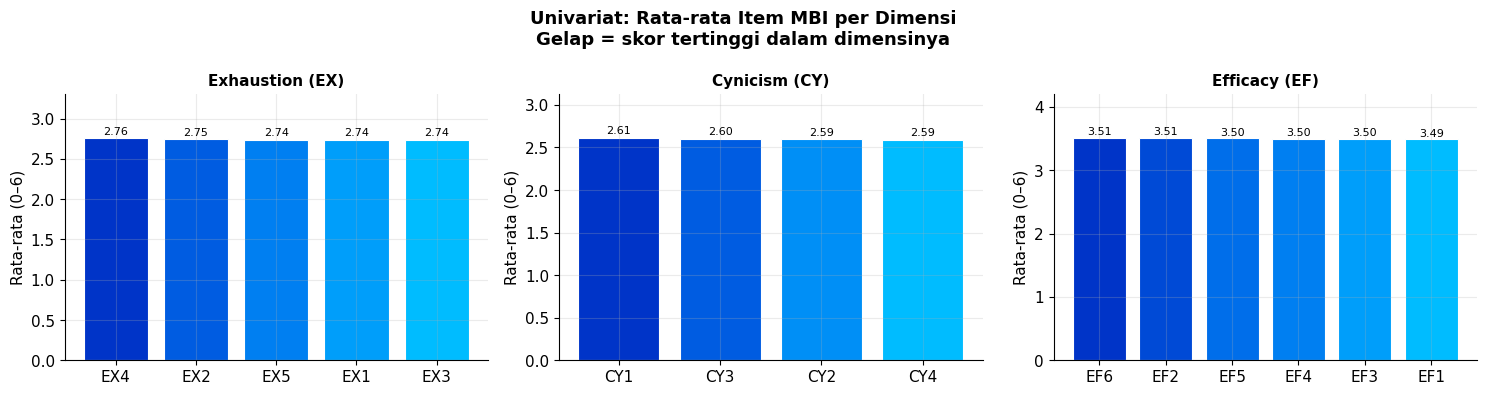

In [24]:
if not df_mbi.empty:
    mbi_ex = [c for c in MBI_EX if c in df_mbi.columns]
    mbi_cy = [c for c in MBI_CY if c in df_mbi.columns]
    mbi_ef = [c for c in MBI_EF if c in df_mbi.columns]
    groups = [('Exhaustion (EX)', mbi_ex),
              ('Cynicism (CY)',    mbi_cy),
              ('Efficacy (EF)',    mbi_ef)]
    groups = [(lbl, cols) for lbl, cols in groups if cols]
    n_groups = len(groups)
    fig, axes = plt.subplots(1, n_groups, figsize=(5*n_groups, 4))
    if n_groups == 1: axes = [axes]
    for ax, (label, cols) in zip(axes, groups):
        means = df_mbi[cols].mean().sort_values(ascending=False)
        n = len(means)
        clrs = [PALETTE_R[int(i*(len(PALETTE_R)-1)/max(n-1,1))] for i in range(n)]
        bars = ax.bar(means.index, means.values, color=clrs, edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, means.values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                    f'{val:.2f}', ha='center', fontsize=8)
        ax.set_ylim(0, means.max()*1.2)
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_ylabel('Rata-rata (0–6)')
        sns.despine(ax=ax)
    fig.suptitle('Univariat: Rata-rata Item MBI per Dimensi\nGelap = skor tertinggi dalam dimensinya',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b3_uni_items.png', dpi=150, bbox_inches='tight'); plt.show()

**Item MBI per Dimensi:** Tiga panel terpisah untuk EX, CY, dan EF. Gradasi dalam tiap panel berdasarkan rata-rata item — item tertinggi paling gelap.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17168\4266212101.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(bp_data, labels=means_dim.index, patch_artist=True,


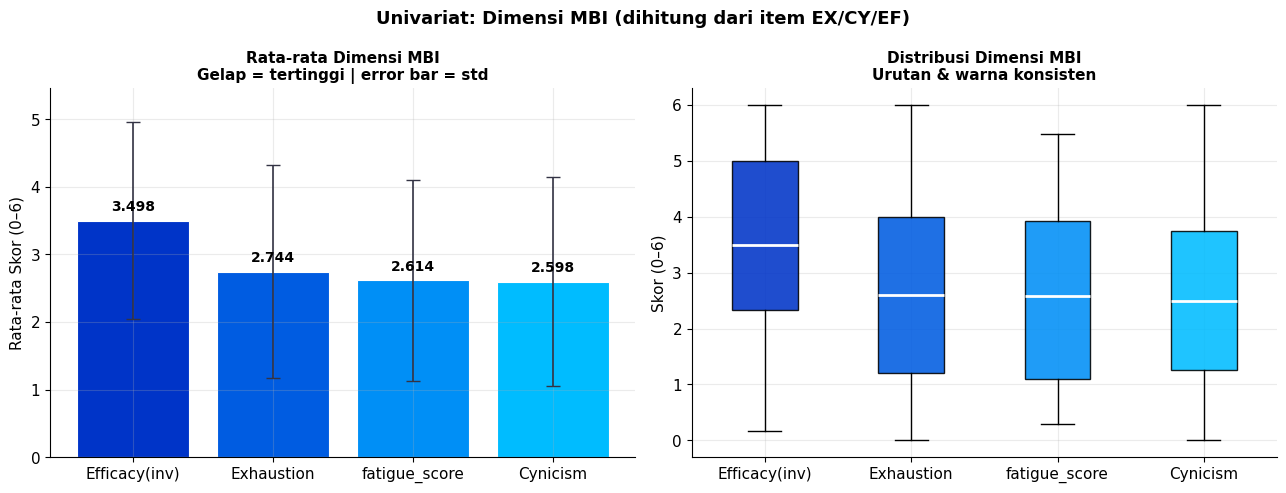

Rata-rata dimensi:
Efficacy(inv)   3.4980
Exhaustion      2.7440
fatigue_score   2.6140
Cynicism        2.5980
dtype: float64


In [25]:
if not df_mbi.empty:
    mbi_ex = [c for c in MBI_EX if c in df_mbi.columns]
    mbi_cy = [c for c in MBI_CY if c in df_mbi.columns]
    mbi_ef = [c for c in MBI_EF if c in df_mbi.columns]

    # Hitung dimensi on-the-fly
    dim_data = {}
    if mbi_ex: dim_data['Exhaustion']    = df_mbi[mbi_ex].mean(axis=1)
    if mbi_cy: dim_data['Cynicism']      = df_mbi[mbi_cy].mean(axis=1)
    if mbi_ef: dim_data['Efficacy(inv)'] = df_mbi[mbi_ef].mean(axis=1)
    if 'fatigue_score' in df_mbi.columns:
        dim_data['fatigue_score'] = df_mbi['fatigue_score']

    df_dim = pd.DataFrame(dim_data)
    means_dim = df_dim.mean().sort_values(ascending=False)
    std_dim   = df_dim.std().reindex(means_dim.index)
    n = len(means_dim)
    clrs = [PALETTE_R[int(i*(len(PALETTE_R)-1)/max(n-1,1))] for i in range(n)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    bars = axes[0].bar(means_dim.index, means_dim.values, color=clrs,
                       edgecolor='white', linewidth=0.8)
    axes[0].errorbar(means_dim.index, means_dim.values, yerr=std_dim.values,
                     fmt='none', color='#334', capsize=5, linewidth=1.2)
    for bar, val in zip(bars, means_dim.values):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                     f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    axes[0].set_ylabel('Rata-rata Skor (0–6)')
    axes[0].set_ylim(0, (means_dim+std_dim).max()+0.5)
    axes[0].set_title('Rata-rata Dimensi MBI\nGelap = tertinggi | error bar = std',
                      fontsize=11, fontweight='bold')
    sns.despine(ax=axes[0])

    bp_data   = [df_dim[c].dropna().values for c in means_dim.index]
    bp = axes[1].boxplot(bp_data, labels=means_dim.index, patch_artist=True,
                          medianprops=dict(color='white', linewidth=2),
                          flierprops=dict(marker='o', markersize=2, color='#556'))
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(clrs[i]); patch.set_alpha(0.88)
    axes[1].set_ylabel('Skor (0–6)')
    axes[1].set_title('Distribusi Dimensi MBI\nUrutan & warna konsisten',
                      fontsize=11, fontweight='bold')
    sns.despine(ax=axes[1])

    fig.suptitle('Univariat: Dimensi MBI (dihitung dari item EX/CY/EF)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b3_uni_dim.png', dpi=150, bbox_inches='tight'); plt.show()
    print('Rata-rata dimensi:')
    print(means_dim.round(3))

**Dimensi MBI Dihitung On-the-Fly:** `Exhaustion = mean(EX1-EX5)`, `Cynicism = mean(CY1-CY4)`, `Efficacy = mean(EF1-EF6)`. Karena kolom `dim_*` tidak ada di file clean, dimensi dihitung langsung dari item individu.

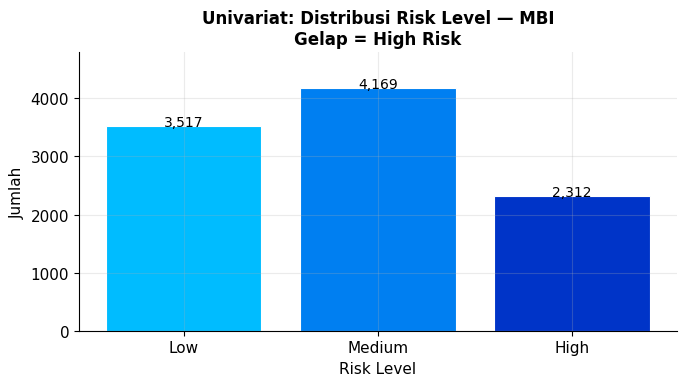

risk_level
Low       3517
Medium    4169
High      2312
Name: count, dtype: int64


In [26]:
if not df_mbi.empty and 'risk_level' in df_mbi.columns:
    risk_avail = [r for r in RISK_ORDER if r in df_mbi['risk_level'].unique()]
    rc_mbi = df_mbi['risk_level'].value_counts().reindex(risk_avail)
    n = len(rc_mbi)
    clrs = [PALETTE[int(i*(len(PALETTE)-1)/max(n-1,1))] for i in range(n)]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(rc_mbi.index, rc_mbi.values, color=clrs, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, rc_mbi.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                f'{val:,}', ha='center', fontsize=10)
    ax.set_ylim(0, rc_mbi.max()*1.15)
    ax.set_xlabel('Risk Level'); ax.set_ylabel('Jumlah')
    ax.set_title('Univariat: Distribusi Risk Level — MBI\nGelap = High Risk',
                 fontsize=12, fontweight='bold')
    sns.despine(ax=ax)
    plt.tight_layout(); plt.savefig('b3_uni_risk.png', dpi=150, bbox_inches='tight'); plt.show()
    print(rc_mbi)

**Distribusi Risk Level MBI:** Imbalanced class distribution memerlukan strategi class weighting atau oversampling saat pemodelan.

### 3.3 Analisis Bivariat MBI Questions

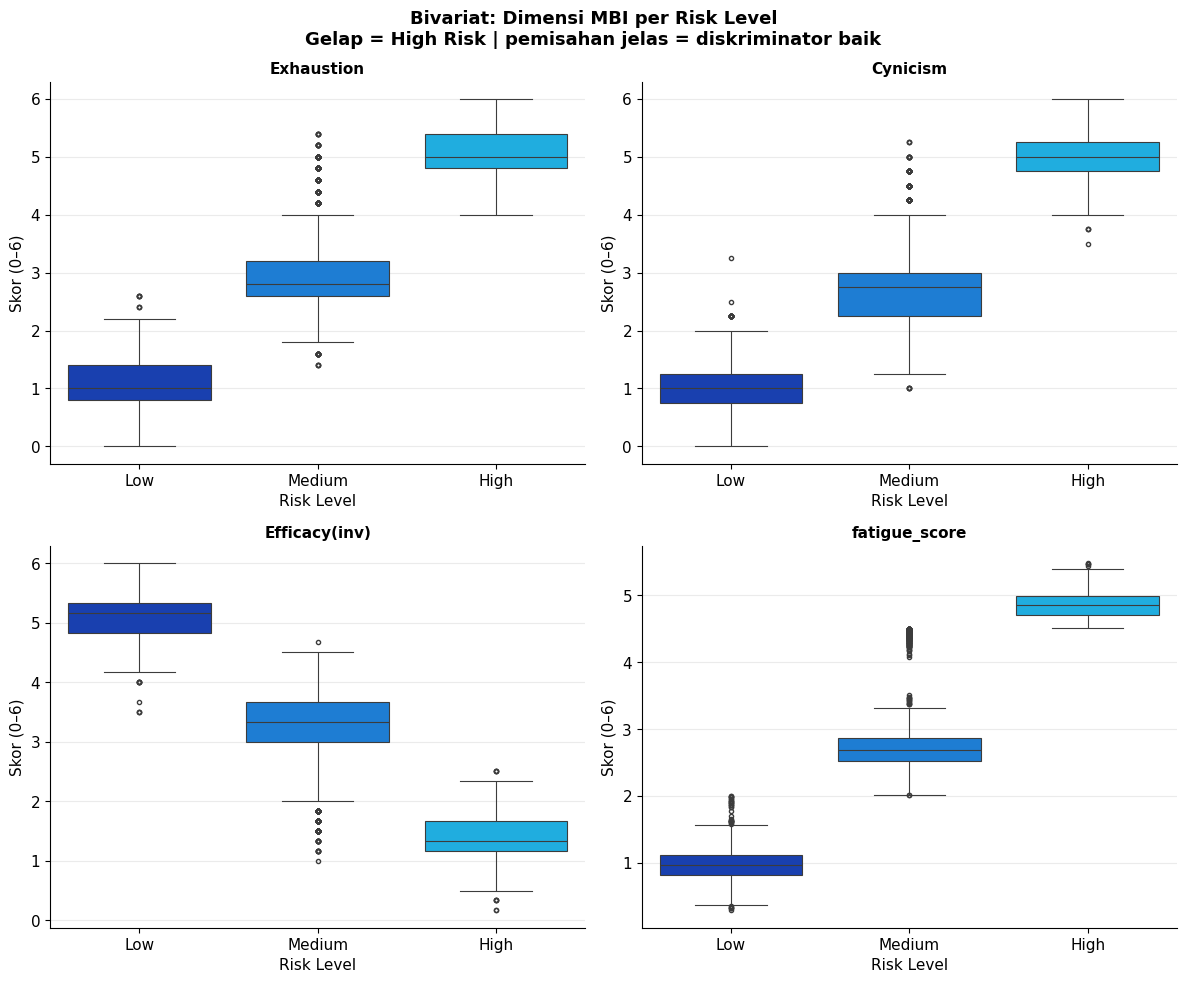

Kruskal-Wallis fatigue_score per risk_level: H=8713.6222, p=0.0000
Kesimpulan: SIGNIFIKAN


In [27]:
if not df_mbi.empty and 'risk_level' in df_mbi.columns:
    mbi_ex = [c for c in MBI_EX if c in df_mbi.columns]
    mbi_cy = [c for c in MBI_CY if c in df_mbi.columns]
    mbi_ef = [c for c in MBI_EF if c in df_mbi.columns]
    dim_data = {}
    if mbi_ex: dim_data['Exhaustion']    = df_mbi[mbi_ex].mean(axis=1)
    if mbi_cy: dim_data['Cynicism']      = df_mbi[mbi_cy].mean(axis=1)
    if mbi_ef: dim_data['Efficacy(inv)'] = df_mbi[mbi_ef].mean(axis=1)
    if 'fatigue_score' in df_mbi.columns:
        dim_data['fatigue_score'] = df_mbi['fatigue_score']
    df_dim = pd.DataFrame(dim_data)
    df_dim['risk_level'] = df_mbi['risk_level'].values

    risk_avail = [r for r in RISK_ORDER if r in df_dim['risk_level'].unique()]
    n = len(risk_avail)
    pal_r = {r: PALETTE_R[int(i*(len(PALETTE_R)-1)/max(n-1,1))] for i,r in enumerate(risk_avail)}
    dim_cols = [c for c in dim_data.keys()]
    ncols = min(2, len(dim_cols)); nrows = (len(dim_cols)+ncols-1)//ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5*nrows))
    axes = np.array(axes).flatten()
    for i, col in enumerate(dim_cols):
        sns.boxplot(data=df_dim, x='risk_level', y=col,
                    hue='risk_level', order=risk_avail, hue_order=risk_avail,
                    palette=pal_r, legend=False, ax=axes[i],
                    linewidth=0.8, flierprops=dict(marker='o', markersize=3))
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('Risk Level'); axes[i].set_ylabel('Skor (0–6)')
        sns.despine(ax=axes[i])
    for j in range(len(dim_cols), len(axes)): axes[j].set_visible(False)
    fig.suptitle('Bivariat: Dimensi MBI per Risk Level\nGelap = High Risk | pemisahan jelas = diskriminator baik',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b3_biv_dim_risk.png', dpi=150, bbox_inches='tight'); plt.show()

    if 'fatigue_score' in dim_data:
        groups_mbi = [df_dim[df_dim['risk_level']==r]['fatigue_score'].dropna() for r in risk_avail]
        stat_kw, p_kw = stats.kruskal(*[g for g in groups_mbi if len(g)>1])
        print(f'Kruskal-Wallis fatigue_score per risk_level: H={stat_kw:.4f}, p={p_kw:.4f}')
        print(f'Kesimpulan: {"SIGNIFIKAN" if p_kw<0.05 else "Tidak signifikan"}')

**Dimensi per Risk Level:** Pemisahan yang jelas (median Low < Medium < High tanpa overlap) menandakan dimensi MBI efektif sebagai diskriminator risk level.

### 3.4 Analisis Multivariat MBI Questions

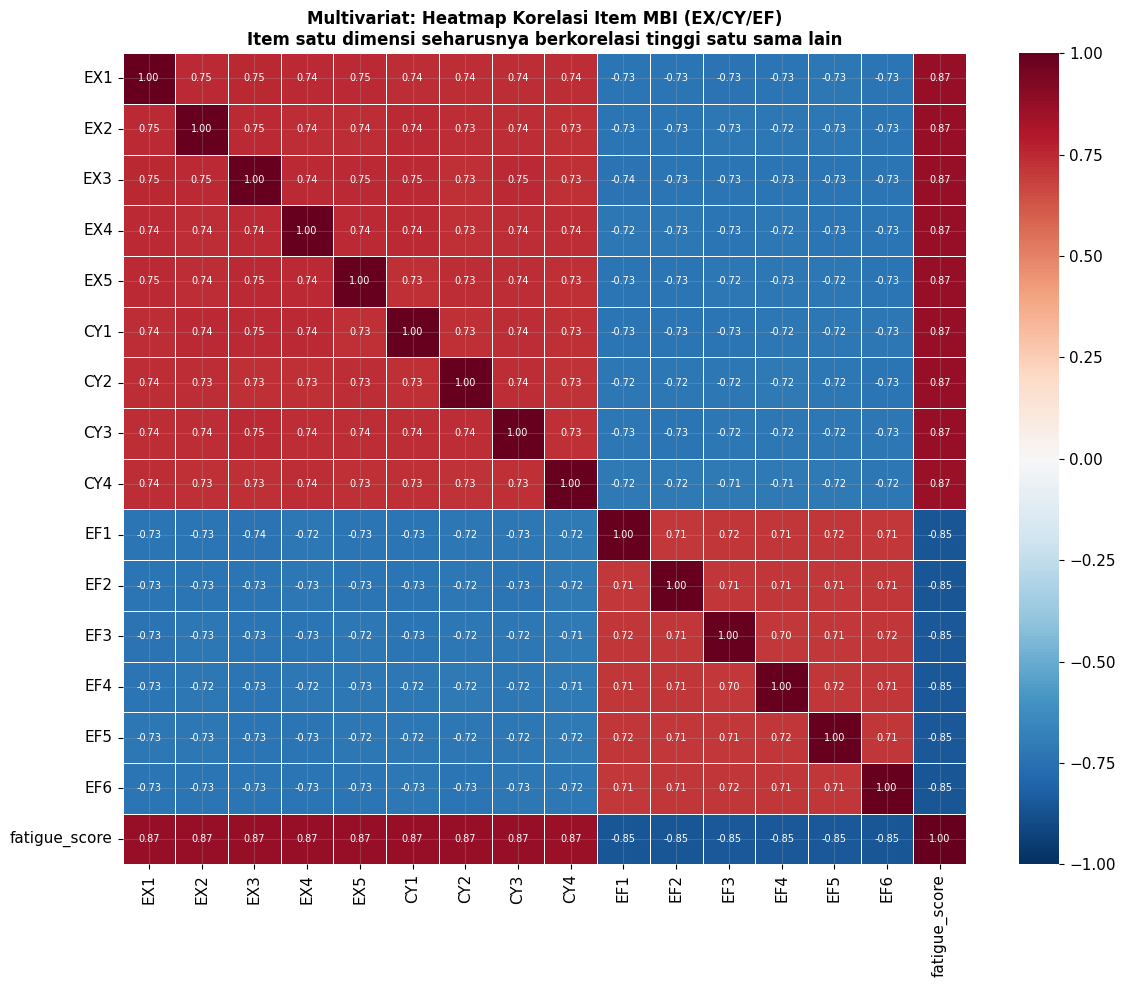

Dimensi dihitung on-the-fly:
               Exhaustion  Cynicism  Efficacy(inv)
Exhaustion         1.0000    0.9250        -0.9360
Cynicism           0.9250    1.0000        -0.9270
Efficacy(inv)     -0.9360   -0.9270         1.0000


In [28]:
if not df_mbi.empty:
    mbi_ex = [c for c in MBI_EX if c in df_mbi.columns]
    mbi_cy = [c for c in MBI_CY if c in df_mbi.columns]
    mbi_ef = [c for c in MBI_EF if c in df_mbi.columns]
    all_items = mbi_ex + mbi_cy + mbi_ef
    if 'fatigue_score' in df_mbi.columns:
        all_items = all_items + ['fatigue_score']
    all_items = [c for c in all_items if c in df_mbi.columns]
    corr_mbi = df_mbi[all_items].corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_mbi, annot=True, fmt='.2f', cmap=HEATMAP_DIV,
                vmin=-1, vmax=1, center=0,
                linewidths=0.5, linecolor='white', ax=ax, annot_kws={'size': 7})
    ax.set_title('Multivariat: Heatmap Korelasi Item MBI (EX/CY/EF)\nItem satu dimensi seharusnya berkorelasi tinggi satu sama lain',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.savefig('b3_multi_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    print('Dimensi dihitung on-the-fly:')
    dim_data2 = {}
    if mbi_ex: dim_data2['Exhaustion']    = df_mbi[mbi_ex].mean(axis=1)
    if mbi_cy: dim_data2['Cynicism']      = df_mbi[mbi_cy].mean(axis=1)
    if mbi_ef: dim_data2['Efficacy(inv)'] = df_mbi[mbi_ef].mean(axis=1)
    df_d2 = pd.DataFrame(dim_data2)
    print(df_d2.corr().round(3))

**Heatmap MBI:** Item dalam satu dimensi (misalnya EX1–EX5) seharusnya berkorelasi tinggi — ini menunjukkan internal consistency instrumen MBI-SS yang valid.

### Dataset 4: Curhat NLP
**Kolom:** `student_id`, `text_curhat` → target: `emotion`


### 4.1 Data Profiling & Assessing

In [29]:
if not df_nlp.empty:
    print('Shape   :', df_nlp.shape)
    print('Kolom   :', df_nlp.columns.tolist())
    print('Missing :', df_nlp.isnull().sum().sum())
    print('Duplikat:', df_nlp.duplicated().sum())
    if 'emotion' in df_nlp.columns:
        print('\nDistribusi emotion:')
        print(df_nlp['emotion'].value_counts())
    if 'text_curhat' in df_nlp.columns:
        print('\nContoh text_curhat:')
        print(df_nlp['text_curhat'].dropna().head(3).tolist())

Shape   : (10000, 3)
Kolom   : ['student_id', 'text_curhat', 'emotion']
Missing : 0
Duplikat: 0

Distribusi emotion:
emotion
Sadness    2935
Fear       2584
Anger      2542
Joy        1157
Neutral     782
Name: count, dtype: int64

Contoh text_curhat:
['Hari ini fokus ke, pergi ke lab komputer jurusan buat mencari referensi jurnal pendukung, biar ga numpuk di akhir minggu.', 'Bener-bener bikin emosi, kerja keras buat revisi yang standarnya terus berubah tapi hasilnya selalu berubah keputusannya setiap pertemuan, padahal udah usaha keras banget.', 'Mental udah di ujung, stuck di progress bimbingan minggu ini gara-gara belum nemu solusi di bagian olah data statistik, capek banget ya Allah.']


**Profiling NLP:** Dataset hanya memiliki 3 kolom. Metrik teks (panjang, kata kunci) perlu dihitung dari kolom `text_curhat`.

In [30]:
if not df_nlp.empty and 'text_curhat' in df_nlp.columns:
    df_nlp = df_nlp.copy()
    df_nlp['word_count']  = df_nlp['text_curhat'].fillna('').apply(lambda x: len(str(x).split()))
    df_nlp['char_count']  = df_nlp['text_curhat'].fillna('').apply(lambda x: len(str(x)))
    STRESS_KW = ['capek','lelah','stres','burnout','deadline','revisi','skripsi',
                 'takut','cemas','panik','nangis','down','menyerah','buntu',
                 'overthinking','gelisah','kewalahan','frustasi','tertekan']
    df_nlp['stress_keyword_count'] = df_nlp['text_curhat'].fillna('').apply(
        lambda x: sum(kw in str(x).lower() for kw in STRESS_KW))
    print('Metrik teks berhasil dihitung:')
    print(df_nlp[['word_count','char_count','stress_keyword_count']].describe().round(2))

Metrik teks berhasil dihitung:
       word_count  char_count  stress_keyword_count
count  10000.0000  10000.0000            10000.0000
mean      22.5000    155.2400                0.7900
std        3.5800     23.0600                0.8000
min       12.0000     88.0000                0.0000
25%       20.0000    138.0000                0.0000
50%       23.0000    156.0000                1.0000
75%       25.0000    172.0000                1.0000
max       33.0000    229.0000                4.0000


**Hitung Metrik Teks:** `word_count`, `char_count`, dan `stress_keyword_count` dihitung langsung dari kolom `text_curhat` menggunakan keyword stres yang sama seperti di notebook 02.

### 4.2 Analisis Univariat Curhat NLP

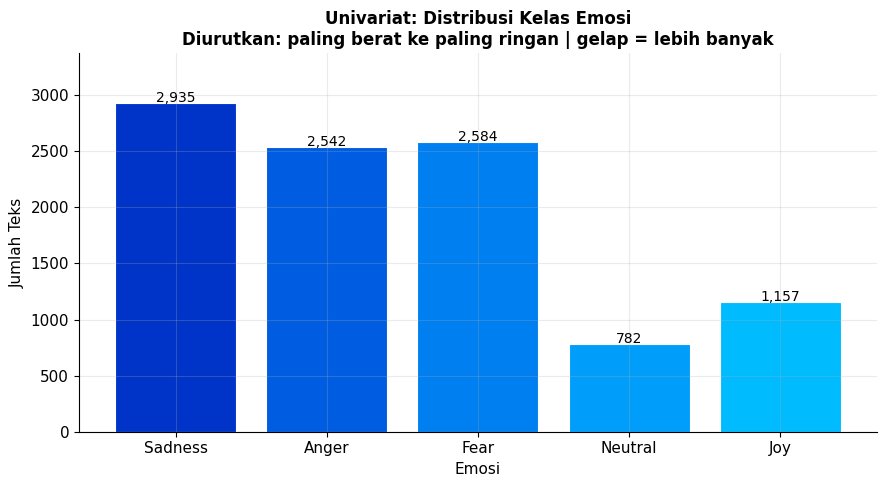

emotion
Sadness    2935
Anger      2542
Fear       2584
Neutral     782
Joy        1157
Name: count, dtype: int64


In [31]:
if not df_nlp.empty and 'emotion' in df_nlp.columns:
    em_order_a = [e for e in EMOTION_ORDER if e in df_nlp['emotion'].unique()]
    em_order_a += [e for e in df_nlp['emotion'].unique() if e not in em_order_a]
    em_counts = df_nlp['emotion'].value_counts().reindex(em_order_a)
    n = len(em_counts)
    clrs = [PALETTE_R[int(i*(len(PALETTE_R)-1)/max(n-1,1))] for i in range(n)]

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(em_counts.index, em_counts.values, color=clrs, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, em_counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                f'{val:,}', ha='center', fontsize=10)
    ax.set_ylim(0, em_counts.max()*1.15)
    ax.set_xlabel('Emosi'); ax.set_ylabel('Jumlah Teks')
    ax.set_title('Univariat: Distribusi Kelas Emosi\nDiurutkan: paling berat ke paling ringan | gelap = lebih banyak',
                 fontsize=12, fontweight='bold')
    sns.despine(ax=ax)
    plt.tight_layout(); plt.savefig('b4_uni_emosi.png', dpi=150, bbox_inches='tight'); plt.show()
    print(em_counts)

**Distribusi Emosi:** Urutan Sadness→Anger→Fear→Neutral→Joy mencerminkan hierarki keparahan psikologis. Kelas imbalanced memerlukan strategi penanganan saat pemodelan.

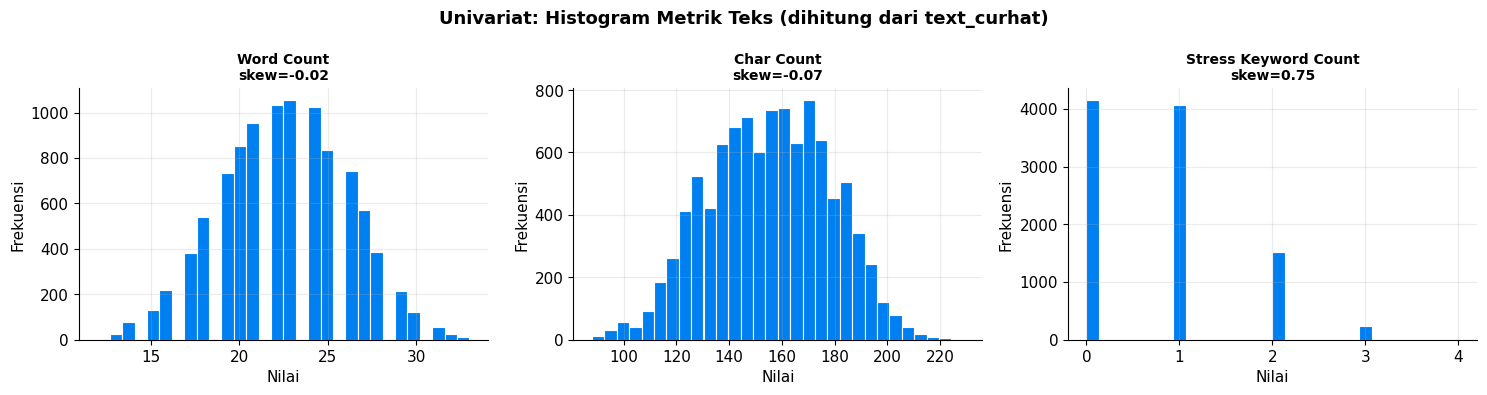

In [32]:
if not df_nlp.empty and 'word_count' in df_nlp.columns:
    metric_cols = [c for c in ['word_count','char_count','stress_keyword_count'] if c in df_nlp.columns]
    n = len(metric_cols)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    for i, col in enumerate(metric_cols):
        skv = df_nlp[col].skew()
        axes[i].hist(df_nlp[col].dropna(), bins=30, color=C_MID, edgecolor='white', linewidth=0.8)
        axes[i].set_title(f'{col.replace("_"," ").title()}\nskew={skv:.2f}',
                          fontsize=10, fontweight='bold')
        axes[i].set_xlabel('Nilai'); axes[i].set_ylabel('Frekuensi')
        sns.despine(ax=axes[i])
    fig.suptitle('Univariat: Histogram Metrik Teks (dihitung dari text_curhat)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b4_uni_metrik.png', dpi=150, bbox_inches='tight'); plt.show()

**Histogram Metrik Teks:** Distribusi right-skewed pada `word_count` dan `char_count` menunjukkan mayoritas teks pendek dengan sebagian kecil teks sangat panjang.

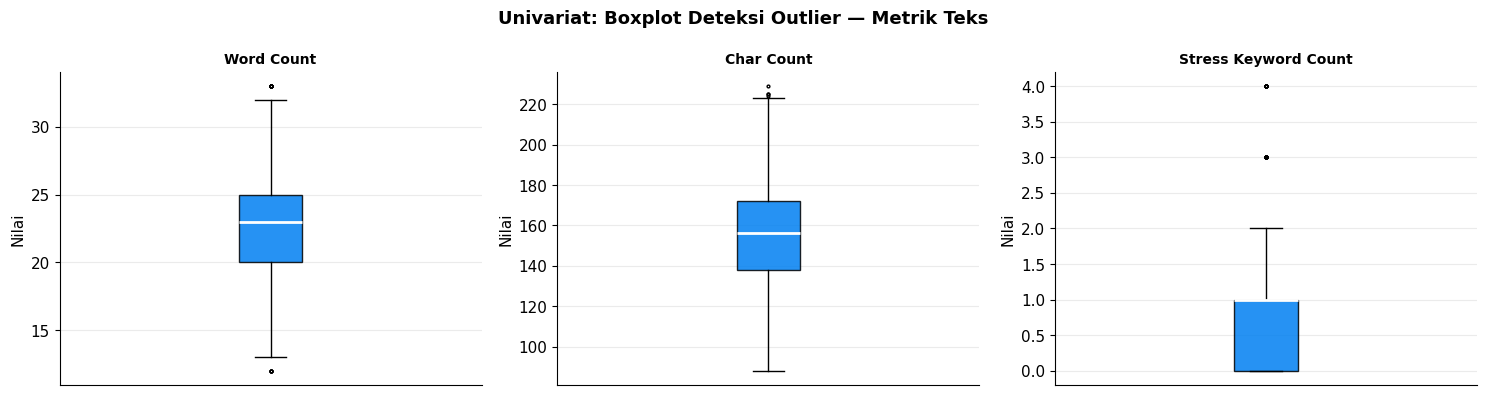

In [33]:
if not df_nlp.empty and 'word_count' in df_nlp.columns:
    metric_cols = [c for c in ['word_count','char_count','stress_keyword_count'] if c in df_nlp.columns]
    n = len(metric_cols)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    for i, col in enumerate(metric_cols):
        bp = axes[i].boxplot(df_nlp[col].dropna(), patch_artist=True,
                              medianprops=dict(color='white', linewidth=2),
                              flierprops=dict(marker='o', markersize=2, color=C_DARK))
        bp['boxes'][0].set_facecolor(C_MID); bp['boxes'][0].set_alpha(0.85)
        axes[i].set_title(col.replace('_',' ').title(), fontsize=10, fontweight='bold')
        axes[i].set_xticks([]); axes[i].set_ylabel('Nilai')
        sns.despine(ax=axes[i])
    fig.suptitle('Univariat: Boxplot Deteksi Outlier — Metrik Teks',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b4_uni_boxplot.png', dpi=150, bbox_inches='tight'); plt.show()

### 4.3 Analisis Bivariat Curhat NLP

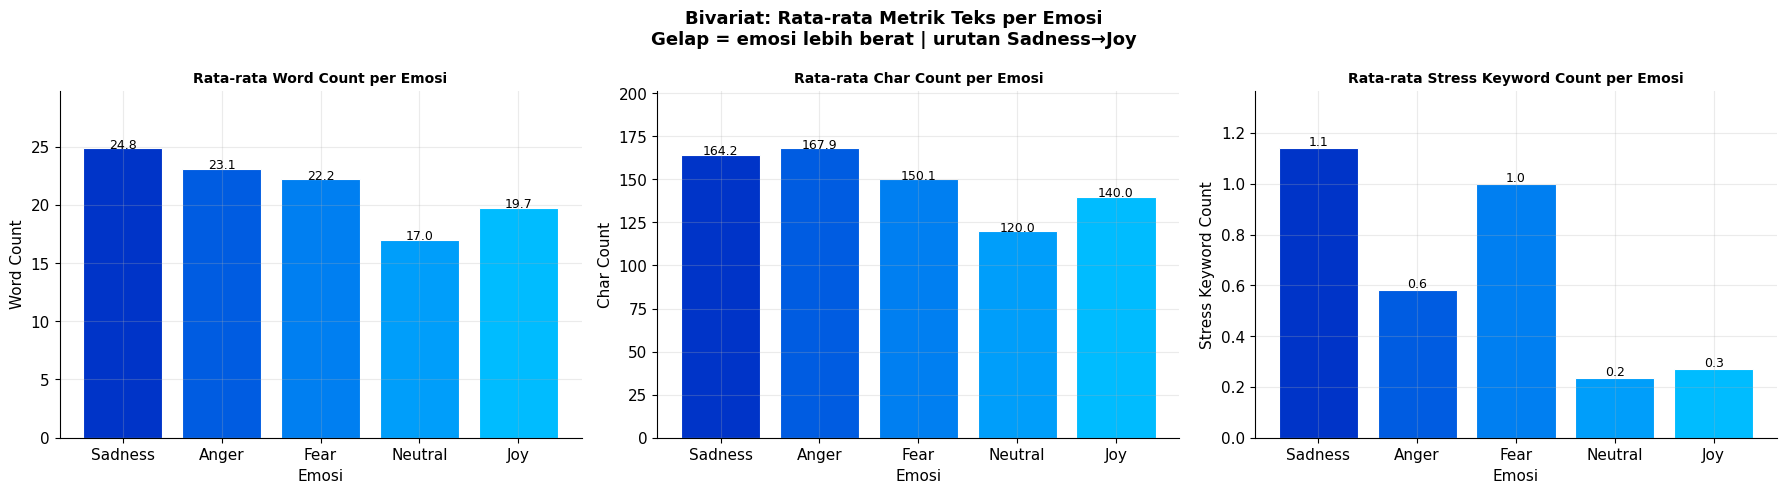

Kruskal-Wallis stress_keyword_count: H=1872.1391, p=0.0000
Kesimpulan: SIGNIFIKAN


In [34]:
if not df_nlp.empty and 'emotion' in df_nlp.columns and 'stress_keyword_count' in df_nlp.columns:
    em_order_a = [e for e in EMOTION_ORDER if e in df_nlp['emotion'].unique()]
    em_order_a += [e for e in df_nlp['emotion'].unique() if e not in em_order_a]
    metric_cols = [c for c in ['word_count','char_count','stress_keyword_count'] if c in df_nlp.columns]
    n = len(metric_cols)
    n_em = len(em_order_a)
    pal_em = {e: PALETTE_R[int(i*(len(PALETTE_R)-1)/max(n_em-1,1))] for i,e in enumerate(em_order_a)}

    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1: axes = [axes]
    for i, col in enumerate(metric_cols):
        kw_means = df_nlp.groupby('emotion')[col].mean().reindex(em_order_a)
        bars = axes[i].bar(kw_means.index, kw_means.values,
                           color=[pal_em[e] for e in kw_means.index],
                           edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, kw_means.values):
            if val == val:
                axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                             f'{val:.1f}', ha='center', fontsize=9)
        axes[i].set_ylim(0, kw_means.max()*1.2)
        axes[i].set_xlabel('Emosi')
        axes[i].set_ylabel(col.replace('_',' ').title())
        axes[i].set_title(f'Rata-rata {col.replace("_"," ").title()} per Emosi',
                          fontsize=10, fontweight='bold')
        sns.despine(ax=axes[i])
    fig.suptitle('Bivariat: Rata-rata Metrik Teks per Emosi\nGelap = emosi lebih berat | urutan Sadness→Joy',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('b4_biv_metrik_emosi.png', dpi=150, bbox_inches='tight'); plt.show()

    kw_groups = [df_nlp[df_nlp['emotion']==e]['stress_keyword_count'].dropna() for e in em_order_a]
    valid_grp = [g for g in kw_groups if len(g)>1]
    if len(valid_grp) >= 2:
        stat_kw, p_kw = stats.kruskal(*valid_grp)
        print(f'Kruskal-Wallis stress_keyword_count: H={stat_kw:.4f}, p={p_kw:.4f}')
        print(f'Kesimpulan: {"SIGNIFIKAN" if p_kw<0.05 else "Tidak signifikan"}')

**Metrik per Emosi:** Bar chart rata-rata menggunakan palet yang sama dengan distribusi emosi dg Sadness paling gelap, Joy paling terang.

### 4.4 Analisis Multivariat Curhat NLP

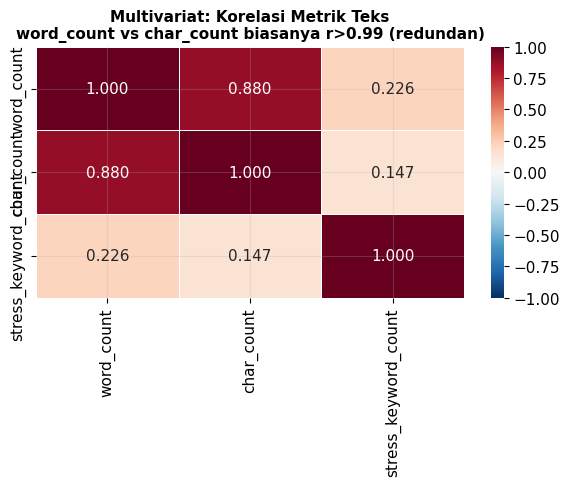

                      word_count  char_count  stress_keyword_count
word_count                1.0000      0.8800                0.2260
char_count                0.8800      1.0000                0.1470
stress_keyword_count      0.2260      0.1470                1.0000


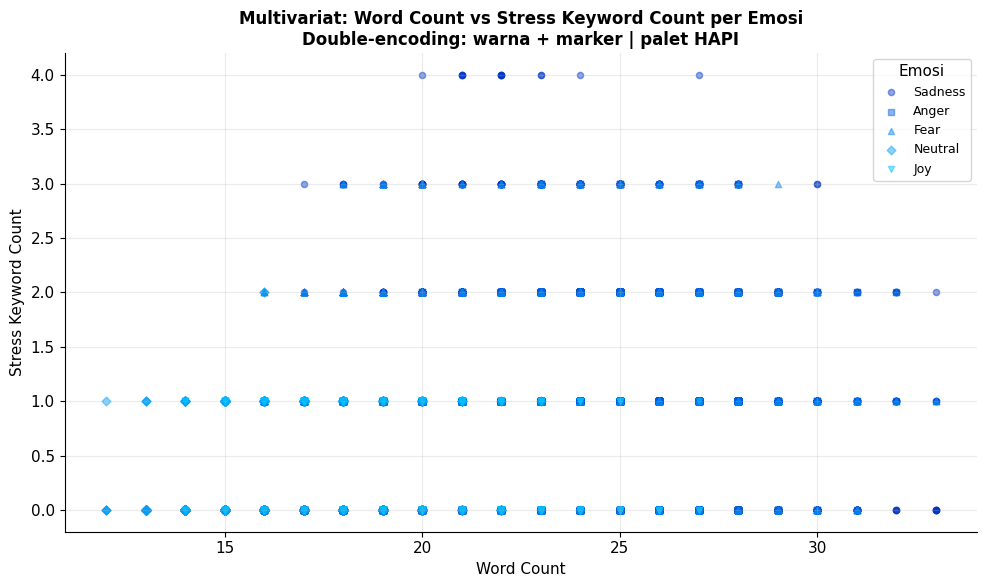

In [35]:
if not df_nlp.empty and 'word_count' in df_nlp.columns:
    metric_cols = [c for c in ['word_count','char_count','stress_keyword_count'] if c in df_nlp.columns]
    if len(metric_cols) >= 2:
        corr_nlp = df_nlp[metric_cols].corr()
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(corr_nlp, annot=True, fmt='.3f', cmap=HEATMAP_DIV,
                    vmin=-1, vmax=1, center=0,
                    linewidths=0.5, linecolor='white', ax=ax, annot_kws={'size': 11})
        ax.set_title('Multivariat: Korelasi Metrik Teks\nword_count vs char_count biasanya r>0.99 (redundan)',
                     fontsize=11, fontweight='bold')
        plt.tight_layout(); plt.savefig('b4_multi_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
        print(corr_nlp.round(3))

if not df_nlp.empty and 'emotion' in df_nlp.columns and 'word_count' in df_nlp.columns and 'stress_keyword_count' in df_nlp.columns:
    em_order_a = [e for e in EMOTION_ORDER if e in df_nlp['emotion'].unique()]
    em_order_a += [e for e in df_nlp['emotion'].unique() if e not in em_order_a]
    n_em = len(em_order_a)
    cmap_em = {e: PALETTE_R[int(i*(len(PALETTE_R)-1)/max(n_em-1,1))] for i,e in enumerate(em_order_a)}
    mkr_em  = {e: m for e,m in zip(em_order_a, ['o','s','^','D','v'])}
    valid = df_nlp[['word_count','stress_keyword_count','emotion']].dropna()
    fig, ax = plt.subplots(figsize=(10, 6))
    for em in em_order_a:
        mask = valid['emotion'] == em
        ax.scatter(valid.loc[mask,'word_count'], valid.loc[mask,'stress_keyword_count'],
                   c=cmap_em[em], marker=mkr_em.get(em,'o'),
                   alpha=0.45, s=20, label=em)
    ax.set_xlabel('Word Count'); ax.set_ylabel('Stress Keyword Count')
    ax.legend(title='Emosi', fontsize=9)
    ax.set_title('Multivariat: Word Count vs Stress Keyword Count per Emosi\nDouble-encoding: warna + marker | palet HAPI',
                 fontsize=12, fontweight='bold')
    sns.despine(ax=ax)
    plt.tight_layout(); plt.savefig('b4_multi_scatter3var.png', dpi=150, bbox_inches='tight'); plt.show()

**Heatmap & Scatter NLP:** `word_count` dan `char_count` hampir selalu r > 0.99 — gunakan salah satu saja. `stress_keyword_count` yang berkorelasi rendah adalah fitur independen yang berharga.

## Ringkasan KPI & Rekomendasi Pemodelan

In [36]:
print('KPI KEBERHASILAN EDA NOTEBOOK 08')
print()
print('1. Kualitas & Integritas Data:')
for name, df in [('burnout',df_burnout),('lifestyle',df_lifestyle),
                  ('mbi',df_mbi),('nlp',df_nlp)]:
    if not df.empty:
        mv  = df.isnull().sum().sum()
        dup = df.duplicated().sum()
        print(f'   {name:10s}: {df.shape[0]:>10,} baris | missing={mv} | duplikat={dup}')
print()
print('2. Distribusi Kelas Target:')
if not df_burnout.empty and 'risk_level' in df_burnout.columns:
    print('   burnout risk_level:', df_burnout['risk_level'].value_counts().to_dict())
if not df_mbi.empty and 'risk_level' in df_mbi.columns:
    print('   mbi     risk_level:', df_mbi['risk_level'].value_counts().to_dict())
if not df_nlp.empty and 'emotion' in df_nlp.columns:
    print('   nlp     emotion   :', df_nlp['emotion'].value_counts().to_dict())
print()
print('3. Rekomendasi per Dataset:')
print('   burnout_fatigue : Regresi (burnout_score) + Klasifikasi (risk_level)')
print('   student_lifestyle: Regresi (Stress_Level) — periksa VIF jam aktivitas')
print('   mbi_questions   : Klasifikasi (risk_level) via fatigue_score + EX/CY/EF')
print('   curhat_nlp      : Klasifikasi (emotion) — gunakan stress_keyword_count + word_count')

KPI KEBERHASILAN EDA NOTEBOOK 08

1. Kualitas & Integritas Data:
   burnout   :  1,000,000 baris | missing=0 | duplikat=0
   lifestyle :      2,000 baris | missing=0 | duplikat=1
   mbi       :      9,998 baris | missing=0 | duplikat=0
   nlp       :     10,000 baris | missing=0 | duplikat=0

2. Distribusi Kelas Target:
   burnout risk_level: {'Low': 766645, 'Medium': 218275, 'High': 15080}
   mbi     risk_level: {'Medium': 4169, 'Low': 3517, 'High': 2312}
   nlp     emotion   : {'Sadness': 2935, 'Fear': 2584, 'Anger': 2542, 'Joy': 1157, 'Neutral': 782}

3. Rekomendasi per Dataset:
   burnout_fatigue : Regresi (burnout_score) + Klasifikasi (risk_level)
   student_lifestyle: Regresi (Stress_Level) — periksa VIF jam aktivitas
   mbi_questions   : Klasifikasi (risk_level) via fatigue_score + EX/CY/EF
   curhat_nlp      : Klasifikasi (emotion) — gunakan stress_keyword_count + word_count


**Rekomendasi Pemodelan**

| Dataset | Model Direkomendasikan | Catatan |
|---|---|---|
| burnout_fatigue | Regresi + Klasifikasi | Periksa VIF; distribusi risk_level mungkin imbalanced |
| student_lifestyle | Regresi (`Stress_Level`) | Kolom `Title_Case`; VIF jam aktivitas perlu dicek |
| mbi_questions | Klasifikasi (`risk_level`) | Hitung `dim_*` dari EX/CY/EF sebelum pemodelan |
| curhat_nlp | Klasifikasi (`emotion`) | Hapus `char_count` (redundan dengan `word_count`) |